**Trabajo Práctico II: Predicción de lluvia en Australia**

Integrantes:

    Manuela Almada
    Elvio Di Prinzio
    Alfredo Sanz


In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-lz_varpu
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-lz_varpu
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other 

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.1 MB/s eta 0:00:00


In [2]:
!pip install geopy openpyxl

Data set de entrada: weatherAUS.csv

Análisis descriptivo de las variables del dataset

Se describen las principales variables del dataset meteorológico australiano (weatherAUS.csv):

Date: Fecha de la observación meteorológica. Permite analizar tendencias temporales y estacionalidad.

Location: Nombre de la localidad donde se tomaron los datos. Es una variable categórica que identifica el punto geográfico.

MinTemp: Temperatura mínima registrada ese día (°C). Variable numérica, su rango depende de la zona y época del año.

MaxTemp: Temperatura máxima registrada ese día (°C). Variable numérica, útil para analizar extremos térmicos.

Rainfall: Precipitación acumulada (mm). Variable numérica, suele tener muchos ceros (días sin lluvia).

Evaporation: Agua evaporada (mm). Variable numérica, relacionada con temperatura y humedad.

Sunshine: Horas de sol. Variable numérica, indica la cantidad de radiación solar recibida.

WindGustDir: Dirección del viento en la ráfaga más fuerte. Variable categórica (N, NE, E, etc.).

WindGustSpeed: Velocidad de la ráfaga más fuerte (km/h). Variable numérica, muestra eventos extremos de viento.

WindDir9am / WindDir3pm: Dirección del viento a las 9am y 3pm. Variables categóricas.

WindSpeed9am / WindSpeed3pm: Velocidad del viento a las 9am y 3pm (km/h). Variables numéricas.

Humidity9am / Humidity3pm: Humedad relativa (%) a las 9am y 3pm. Variables numéricas, rango 0-100.

Pressure9am / Pressure3pm: Presión atmosférica (hPa) a las 9am y 3pm. Variables numéricas, rango típico 1000-1030 hPa.

Cloud9am / Cloud3pm: Cobertura de nubes (octas) a las 9am y 3pm. Variables numéricas, rango 0-8.

Temp9am / Temp3pm: Temperatura a las 9am y 3pm (°C). Variables numéricas.

RainToday: Indica si llovió ese día (Yes/No). Variable categórica binaria.

RainTomorrow: Variable objetivo, indica si lloverá al día siguiente (Yes/No).

In [4]:
# ============================================================================
# TRABAJO PRÁCTICO: PREDICCIÓN DE LLUVIA EN AUSTRALIA
# Versión Completa y Ordenada
# Python 3.11+ (incluye PyCaret)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import optuna
import warnings
warnings.filterwarnings('ignore')

import shap

# Geo
from geopy.geocoders import Nominatim

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, StratifiedKFold, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score, r2_score, mean_absolute_error, ConfusionMatrixDisplay
)

# Configuración
plt.style.use('ggplot')
sns.set_palette('deep')

print("="*80)
print("TRABAJO PRÁCTICO: PREDICCIÓN DE LLUVIA EN AUSTRALIA")
print("="*80)



TRABAJO PRÁCTICO: PREDICCIÓN DE LLUVIA EN AUSTRALIA


### Acerca de las Localidades y de las Regiones:
Se encontró un archivo con las ciudades australianas y sus coordenadas en https://simplemaps.com/data/au-cities pero presentaba muchas diferencias de nombres con las localidades del data set weatherAUS.csv con lo cual se lo descartó como referencia de latitud y longitud. Posteriormente se consultaron a chatGPT cuales eran las latitudes y longitudes que correspondían a las 49 localidades que comprenden weatherAUS.csv incluyendo la fuente de información de donde se extrajo el dato. Este data set se denomina "localidades_australia_nuevo.csv" y es el que usamos finalmente para el trabajo.

In [5]:
# ============================================================================
# 1. CARGA Y FUSIÓN DE DATOS
# ============================================================================
print("\n[1] CARGA Y FUSIÓN DE DATOS")
print("-" * 80)

try:
    df_raw = pd.read_csv('weatherAUS.csv')
    print(f"✓ Datos 'weatherAUS.csv' cargados: {df_raw.shape}")
except FileNotFoundError:
    df_raw = pd.DataFrame(columns=['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
                                    'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
                                    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                                    'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud33pm', 'Temp9am',
                                    'Temp3pm', 'RainToday', 'RainTomorrow'])
    print("⚠ Error: No se encontró el archivo 'weatherAUS.csv'")

try:
    df_localidades = pd.read_csv('localidades_australia_nuevo.csv')
    print(f"✓ Datos 'localidades_australia_nuevo.csv' cargados: {df_localidades.shape}")
except FileNotFoundError:
    df_localidades = pd.DataFrame({'Localidad': df_raw['Location'].unique() if not df_raw.empty else [],
                                    'Latitud': np.nan, 'Longitud': np.nan, 'Fuente': 'N/A'})
    print("⚠ No se encontró el archivo de localidades")

df_full = pd.merge(df_raw, df_localidades, left_on='Location', right_on='Localidad', how='left')
print(f"✓ DataFrames fusionados: {df_full.shape}")



[1] CARGA Y FUSIÓN DE DATOS
--------------------------------------------------------------------------------
✓ Datos 'weatherAUS.csv' cargados: (145460, 23)
✓ Datos 'localidades_australia_nuevo.csv' cargados: (49, 4)
✓ DataFrames fusionados: (145460, 27)



[2] CLUSTERING GEOGRÁFICO: CREACIÓN DE REGIONES
--------------------------------------------------------------------------------
✓ Variable 'Region' creada a partir de clustering

Distribución de registros por región:
Region
South Australia                 52277
Northern Territory              30582
Tasmania                        21267
Australian Capital Territory    19847
Queensland                       7627
Victoria                         6080
New South Wales                  4771
Western Australia                3009
Name: count, dtype: int64


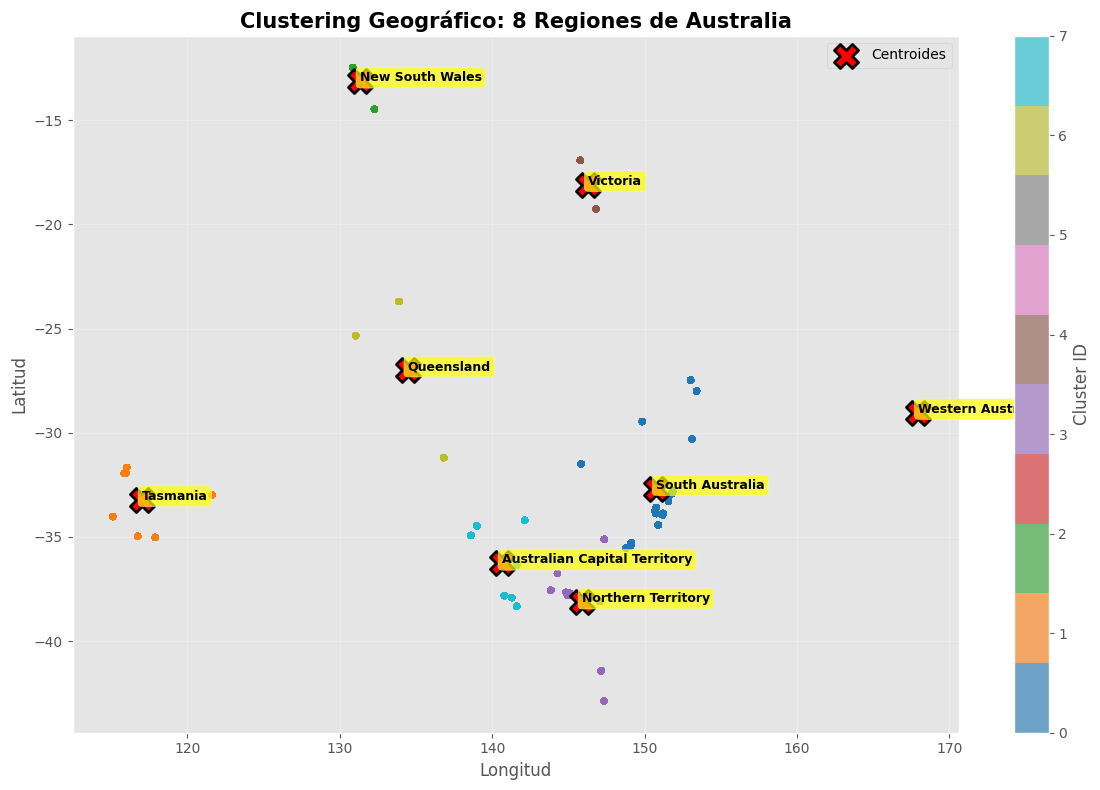

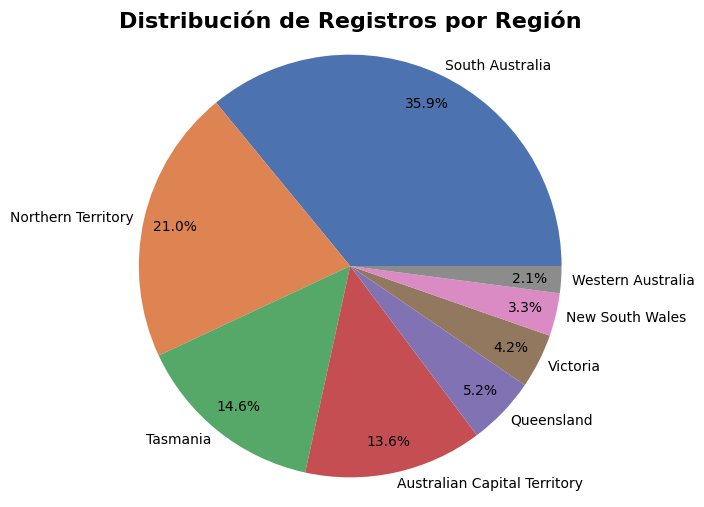

In [6]:
# ============================================================================
# 2. CLUSTERING GEOGRÁFICO
# ============================================================================
print("\n[2] CLUSTERING GEOGRÁFICO: CREACIÓN DE REGIONES")
print("-" * 80)

X_coords = df_full[['Latitud', 'Longitud']].dropna()

if not X_coords.empty:
    kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
    kmeans.fit(X_coords)

    df_full['Cluster'] = np.nan
    df_full.loc[X_coords.index, 'Cluster'] = kmeans.labels_

    nombres_regiones = [
        'New South Wales', 'Victoria', 'Queensland', 'Western Australia',
        'South Australia', 'Tasmania', 'Australian Capital Territory', 'Northern Territory'
    ]

    centroides = kmeans.cluster_centers_
    orden_centroides = np.argsort(centroides[:,0])[::-1]
    cluster_a_nombre = {orden_centroides[i]: nombres_regiones[i] for i in range(len(nombres_regiones))}

    df_full['Region'] = df_full['Cluster'].map(cluster_a_nombre)

    print("✓ Variable 'Region' creada a partir de clustering")
    print("\nDistribución de registros por región:")
    print(df_full['Region'].value_counts())

    # GRÁFICO 1: Mapa de regiones
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_coords['Longitud'], X_coords['Latitud'],
                         c=df_full.loc[X_coords.index, 'Cluster'],
                         cmap='tab10', alpha=0.6, s=20)
    plt.scatter(centroides[:, 1], centroides[:, 0],
               c='red', marker='X', s=300, edgecolors='black', linewidths=2,
               label='Centroides')

    for i, (lat, lon) in enumerate(centroides):
        plt.annotate(nombres_regiones[orden_centroides.tolist().index(i)],
                    (lon, lat), fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

    plt.xlabel('Longitud', fontsize=12)
    plt.ylabel('Latitud', fontsize=12)
    plt.title('Clustering Geográfico: 8 Regiones de Australia', fontsize=15, fontweight='bold')
    plt.colorbar(scatter, label='Cluster ID')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # GRÁFICO 2: Pie chart
    df_regions = df_full['Region'].value_counts().reset_index()
    df_regions.columns = ['Region', 'Count']
    df_regions = df_regions.sort_values(by='Count', ascending=False)

    plt.figure(figsize=(6, 6))
    plt.pie(df_regions['Count'], labels=df_regions['Region'], autopct='%1.1f%%',
            startangle=0, pctdistance=0.85, labeldistance=1.05)
    plt.title('Distribución de Registros por Región', fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.show()

    df_full = df_full.drop(columns=['Cluster'])
else:
    df_full['Region'] = 'Unknown'
    print("⚠ No se pudo realizar clustering por falta de coordenadas")


### 4. Análisis Exploratorio de Datos (EDA)

In [7]:
# ============================================================================
# 3. ANÁLISIS DESCRIPTIVO
# ============================================================================
print("\n[3] ANÁLISIS DESCRIPTIVO DE VARIABLES")
print("-" * 80)

print("\n3.1 Información General del Dataset")
print(f"Dimensiones: {df_full.shape}")
print(f"\nTipos de datos:")
print(df_full.dtypes.value_counts())

print("\n3.2 Estadísticas Descriptivas (Variables Numéricas)")
print(df_full.describe().T)

# 3.3 ANÁLISIS DE DATOS FALTANTES
print("\n3.3 Análisis de Datos Faltantes")
missing_values = df_full.isna().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(df_full) * 100).round(2)
missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Faltantes': missing_values.values,
    'Porcentaje': missing_percent.values
})
missing_df = missing_df[missing_df['Faltantes'] > 0]

print("\nTop 10 columnas con más datos faltantes:")
print(missing_df.head(10))


[3] ANÁLISIS DESCRIPTIVO DE VARIABLES
--------------------------------------------------------------------------------

3.1 Información General del Dataset
Dimensiones: (145460, 28)

Tipos de datos:
float64    18
object     10
Name: count, dtype: int64

3.2 Estadísticas Descriptivas (Variables Numéricas)
                  count         mean        std        min        25%  \
MinTemp        143975.0    12.194034   6.398495   -8.50000     7.6000   
MaxTemp        144199.0    23.221348   7.119049   -4.80000    17.9000   
Rainfall       142199.0     2.360918   8.478060    0.00000     0.0000   
Evaporation     82670.0     5.468232   4.193704    0.00000     2.6000   
Sunshine        75625.0     7.611178   3.785483    0.00000     4.8000   
WindGustSpeed  135197.0    40.035230  13.607062    6.00000    31.0000   
WindSpeed9am   143693.0    14.043426   8.915375    0.00000     7.0000   
WindSpeed3pm   142398.0    18.662657   8.809800    0.00000    13.0000   
Humidity9am    142806.0    68.880831

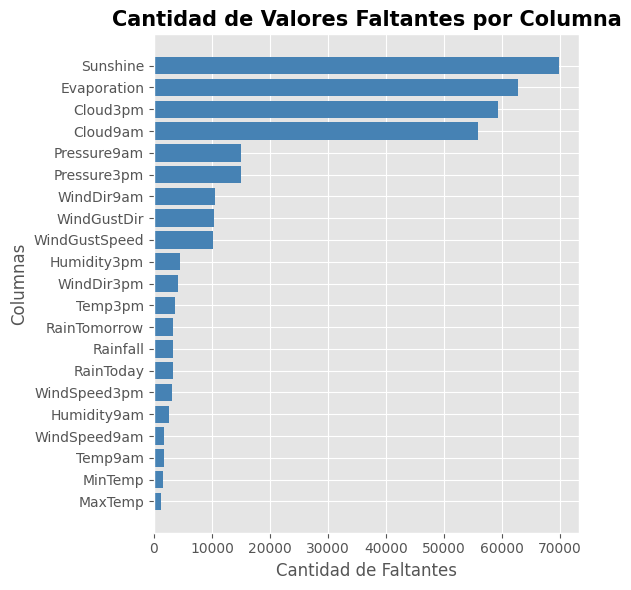

In [8]:
# GRÁFICO 3: Visualización de faltantes
missing_to_plot = missing_values[missing_values > 0]
if not missing_to_plot.empty:
    plt.figure(figsize=(6, 6))
    plt.barh(missing_to_plot.index, missing_to_plot.values, color='steelblue')
    plt.title('Cantidad de Valores Faltantes por Columna', fontsize=15, fontweight='bold')
    plt.xlabel('Cantidad de Faltantes', fontsize=12)
    plt.ylabel('Columnas', fontsize=12)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Se observa una fuerte desproporción de faltantes en función del atributo. Vamos a definir estrategias distintas para atenuar este tema en cada caso particular.

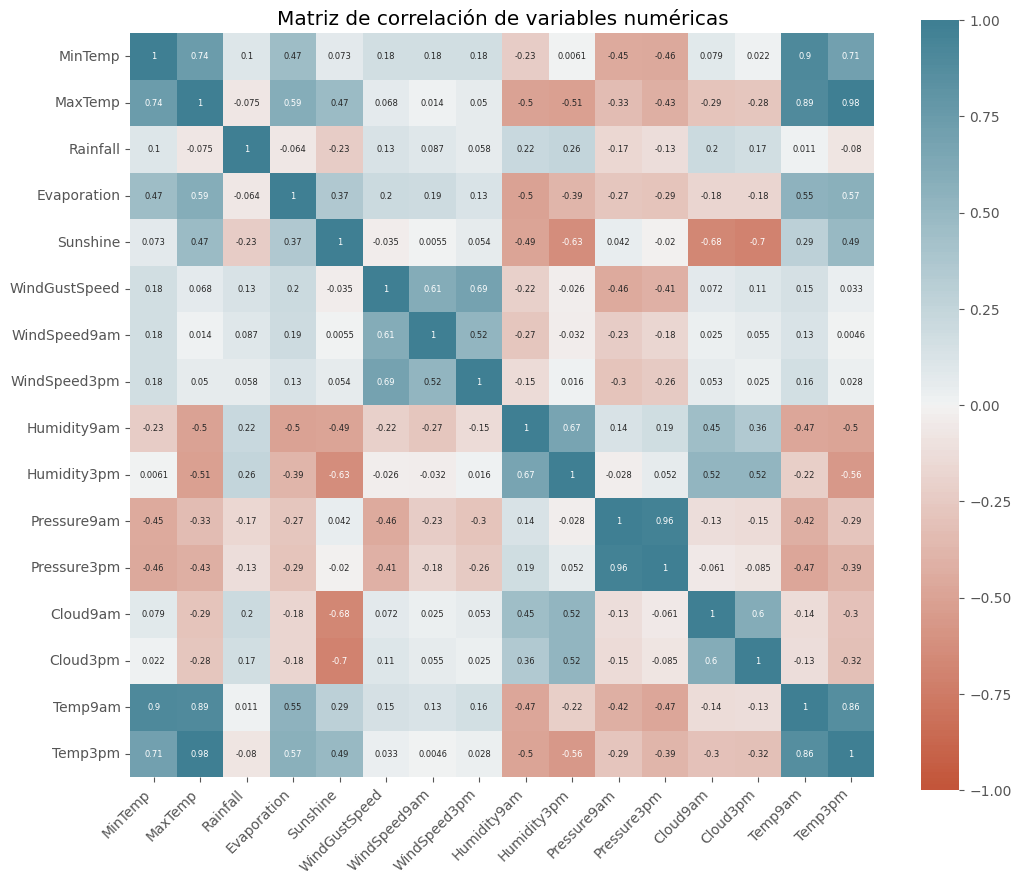

In [9]:
# ### 4.2 ¿Qué nos dicen los Datos?

# Matriz de correlación
n_columns = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
             'Sunshine', 'WindGustSpeed', 'WindSpeed9am',
             'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
             'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
             'Temp3pm']

corr = df_full[n_columns].corr(method='pearson')
plt.figure(figsize=(12,10))
plt.title('Matriz de correlación de variables numéricas')
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.show()


In [10]:
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable1', 'Variable2', 'Correlation']

# Quitar duplicados y la diagonal (correlación consigo misma = 1)
corr_pairs = corr_pairs[corr_pairs['Variable1'] != corr_pairs['Variable2']]
corr_pairs = corr_pairs.drop_duplicates(subset=['Correlation'])

# Ordenar por el valor absoluto de la correlación (de mayor a menor)
corr_pairs = corr_pairs.reindex(corr_pairs['Correlation'].abs().sort_values(ascending=False).index)

print('Top 30 variables con mayor correlación')
print(corr_pairs.head(30))

Top 30 variables con mayor correlación
         Variable1     Variable2  Correlation
31         MaxTemp       Temp3pm     0.984503
171    Pressure9am   Pressure3pm     0.961326
14         MinTemp       Temp9am     0.901821
30         MaxTemp       Temp9am     0.887210
239        Temp9am       Temp3pm     0.860591
1          MinTemp       MaxTemp     0.736555
15         MinTemp       Temp3pm     0.708906
77        Sunshine      Cloud3pm    -0.703930
87   WindGustSpeed  WindSpeed3pm     0.686307
76        Sunshine      Cloud9am    -0.675323
137    Humidity9am   Humidity3pm     0.666949
73        Sunshine   Humidity3pm    -0.629130
86   WindGustSpeed  WindSpeed9am     0.605303
205       Cloud9am      Cloud3pm     0.603564
19         MaxTemp   Evaporation     0.587932
63     Evaporation       Temp3pm     0.572893
159    Humidity3pm       Temp3pm    -0.557841
62     Evaporation       Temp9am     0.545115
157    Humidity3pm      Cloud3pm     0.523120
103   WindSpeed9am  WindSpeed3pm     0.51

Conclusiones del Heatmap
1. 🌡️ Fuerte Multicolinealidad entre Variables de Temperatura y Presión
Se observa una correlación positiva casi perfecta (valores muy cercanos a 1.0, en rojo brillante) entre varios pares de variables.

MaxTemp y Temp3pm (0.98): Son casi la misma variable. La temperatura máxima del día y la temperatura a las 3 PM son redundantes.

MinTemp y Temp9am (0.90): Similarmente, la temperatura mínima está fuertemente ligada a la temperatura de la mañana.

Pressure9am y Pressure3pm (0.96): La presión atmosférica a las 9 AM y a las 3 PM apenas cambia en términos relativos.

Para tener en cuenta:
Si mantenemos todos estos pares de variables en un modelo lineal (como la Regresión Logística) es problemático. Causa multicolinealidad, lo que infla la varianza de los coeficientes del modelo, haciéndolos inestables y difíciles de interpretar. Para el feature selection, deberíamos elegir solo una variable de cada par (ej. MaxTemp en lugar de Temp3pm).

2. ☁️ Correlaciones Negativas Lógicas (Validación de Coherencia)
Tenemos fuertes correlaciones negativas (valores cercanos a -1.0, en morado oscuro) que validan la coherencia de los datos.

Sunshine y Cloud3pm (-0.70): Esta es la correlación negativa más fuerte. Es lógicamente intuitivo: a mayor nubosidad (Cloud3pm), menor cantidad de horas de sol (Sunshine).

Sunshine y Cloud9am (-0.68): La misma lógica se aplica a la nubosidad matutina.

Sunshine y Humidity3pm (-0.63): Los días con alta humedad por la tarde (que suele preceder a la lluvia) tienden a ser menos soleados.

Esto podemos considerarlo como "una buena señal": las variables se comportan como se esperaría en el mundo real lo cual nos da confianza sobre la calidad del dataset.

3. 💧 Identificación de Predictores Clave para la Lluvia
Si observamos la fila/columna RainToday (sería el "proxy" de nuestro objetivo final, RainTomorrow), podemos identificar qué variables están más asociadas con la lluvia.

Correlación Positiva: Las variables con mayor correlación positiva (aunque moderada) con RainToday son Rainfall (0.50) (bastante obvio: si llueve, el rainfall es > 0), Humidity3pm (0.32), Cloud3pm (0.32) y Cloud9am (0.30).

Correlación Negativa: La variable con mayor correlación negativa es Sunshine (-0.33).

Esto es una indicación que permite anticipar que la humedad y la nubosidad (especialmente por la tarde) serán variables muy influyentes para predecir lluvia: alta humedad y alta nubosidad van a incrementan la probabilidad de lluvia.

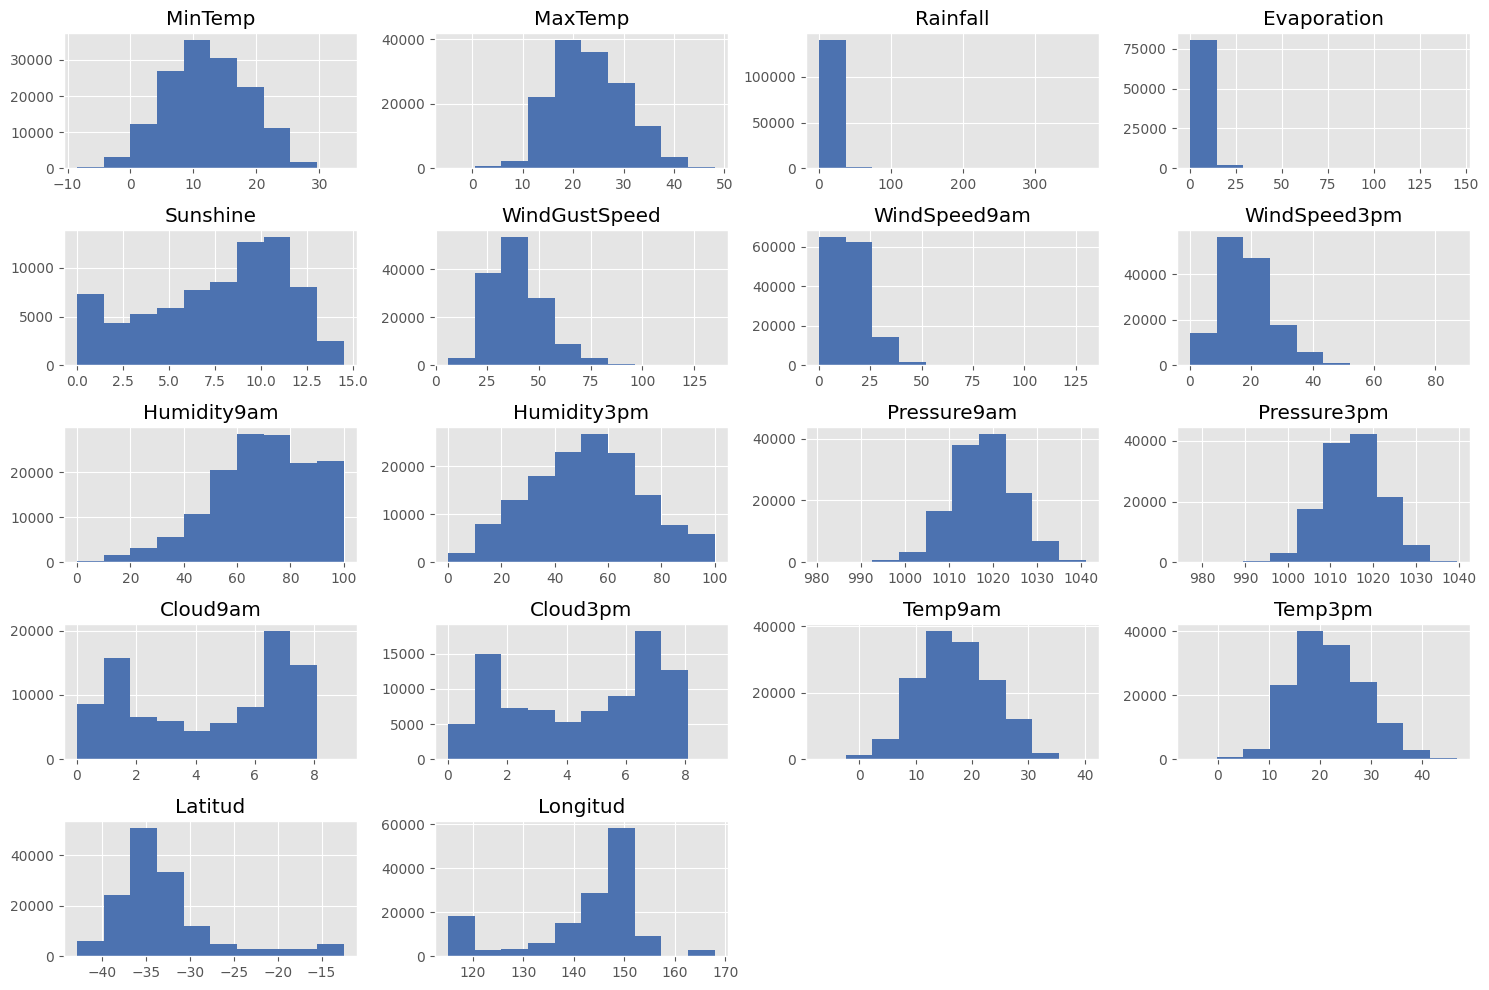

In [ ]:
df_full.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

¿Qué observamos en los histogramas?

1. 📈 Asimetría Dominante: la mayoría de las variables no siguen una distribución normal.

Sesgo a la Derecha: Las variables **Rainfall** y **Evaporation** están fuertemente sesgadas a la derecha. El eje Y esté en escala logarítmica (log=True) lo que confirma que la gran mayoría de los registros tienen valores de 0 o muy cercanos a 0, con muy pocos valores atípicos altos.

Las variables de viento (WindGustSpeed, WindSpeed9am, WindSpeed3pm) también muestran un sesgo a la derecha más moderado.

Sesgo a la Izquierda: Humidity9am está sesgada a la izquierda, indicando que es más común tener mañanas con humedad alta o muy alta.

2. 🔔 Variabilidad en las Distribuciones

Humidity3pm, Pressure9am y Pressure3pm: Estas son las variables más simétricas y parecidas a una campana (distribución normal). Son candidatas a predictoras importantes por su distribución centrada (variables estables).


3. ⚙️ ¿Cómo puede afectar ésto al Modelado?

Para Modelos Lineales (Ej. Regresión Logística): Estos modelos se verán muy afectados por la asimetría. Será necesario evaluar la aplicación de transformaciones de datos (como la transformación logarítmica o raíz cuadrada) para "normalizar" estas variables antes de entrenar el modelo.

Para Modelos Basados en Árboles (Ej. Random Forest): Estos modelos son robustos a la asimetría y a la escala de las variables. Probablemente manejarán bien estos datos "crudos" (o simplemente escalados) sin necesidad de transformaciones complejas para corregir el sesgo.

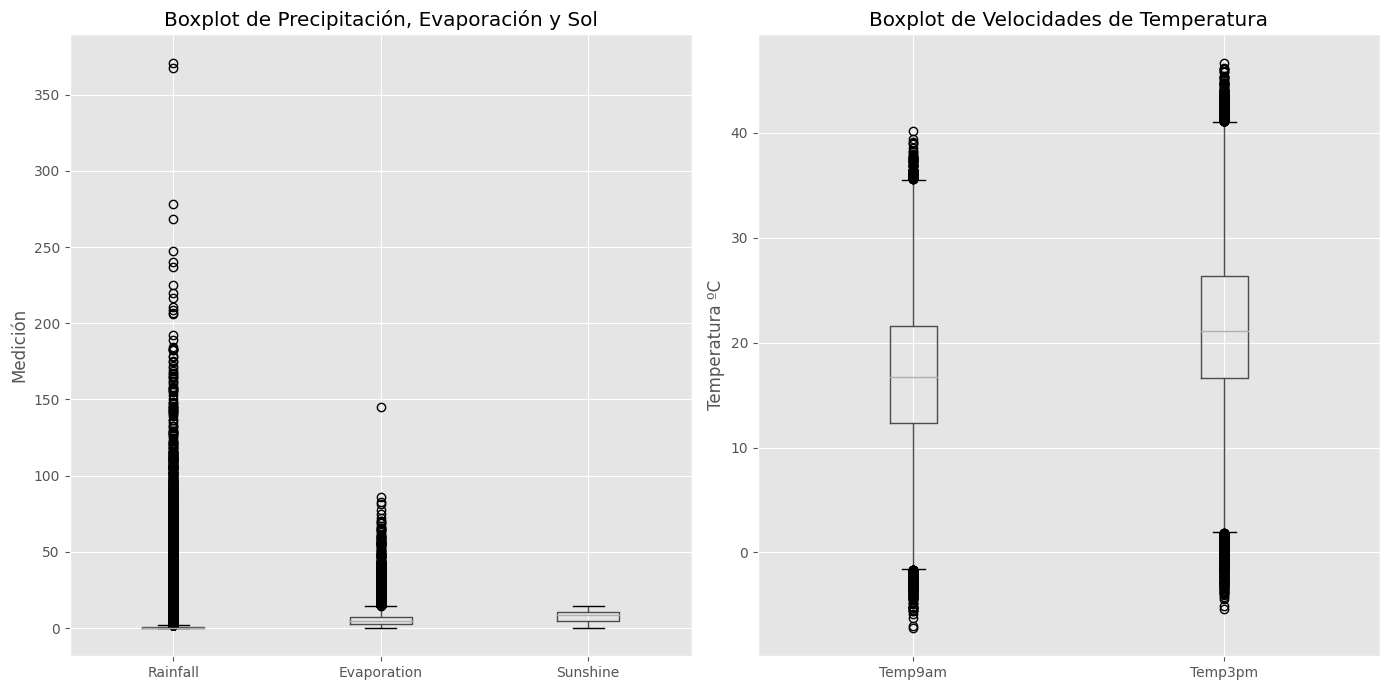

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

df_full[['Rainfall', 'Evaporation', 'Sunshine']].boxplot(ax=axes[0])
axes[0].set_title('Boxplot de Precipitación, Evaporación y Sol')
axes[0].set_ylabel('Medición')

# ¡Aquí pones las variables para tu segundo gráfico!
# Como ejemplo, uso las variables de viento:
df_full[['Temp9am', 'Temp3pm']].boxplot(ax=axes[1])
axes[1].set_title('Boxplot de Velocidades de Temperatura')
axes[1].set_ylabel('Temperatura ºC') # Ajusta esta etiqueta

plt.tight_layout()
plt.show()

¿Qué obsrvamos en los boxplots?

Hay una clara distinción en la distribución y el comportamiento de las variables.

Rainfall y Evaporation presentan alta asimetría y la presencia de numerosos valores atípicos.

¿Que reflehja ésto de la realidad?
1) Que hay un número considerable de días con eventos de lluvia intensa.
2) Que la evaporación tiende a ser baja o moderada la mayoría de los días, con algunos picos.

Las variables de temperatura (Temp9am, Temp3pm) muestran distribuciones mucho más regulares y simétricas, con menos problemas de valores extremos, lo que las hace más "fáciles" de manejar en el proceso de modelado.

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


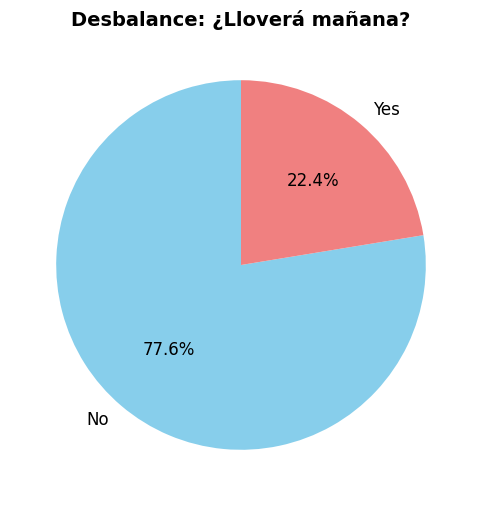


 DATASET DESBALANCEADO DETECTADO
-> Usaremos SMOTE para balancear el conjunto de entrenamiento


In [ ]:
# ### 4.3 Análisis de Desbalance de la Variable Target
df_full['RainTomorrow'] = df_full['RainTomorrow'].astype('category')
counts = df_full["RainTomorrow"].value_counts()
print(counts)

plt.figure(figsize=(6, 6))
counts.plot(kind='pie', colors=['skyblue', 'lightcoral'], autopct='%1.1f%%',
            startangle=90, fontsize=12)
plt.title("Desbalance: ¿Lloverá mañana?", fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

if counts['No'] / counts['Yes'] > 2:
    print("\n DATASET DESBALANCEADO DETECTADO")
    print("-> Usaremos SMOTE para balancear el conjunto de entrenamiento")


Observamos en el gráfico que nuestro dataset presenta un **fuerte desbalance en la variable target** . Debemos prestar mucha atención a ésto: si el desbalance persiste al momento de entrenar el modelo, es muy probable que este tienda a predecir con mayor frecuencia la clase mayoritaria (en este caso, “No va a llover”).

Esto ocurre porque el modelo puede alcanzar una aparente "alta precisión" simplemente prediciendo siempre la clase dominante, pero a costa de un bajo desempeño en la detección de los días en que sí llueve, que justamente es lomás interesante de  un problema de predicción meteorológica.

### 5. Preparación de Datos
Tareas:
1. Vamos a eliminar filas donde la variable objetivo ('RainTomorrow') es nula.
2. Mapeamos la variable objetivo a valores binarios (0/1).
3. Separamos los datos en conjuntos de Entrenamiento y Prueba (Test).

In [11]:
# ### 5.1 Limpieza Inicial y División de Datos
## Eliminamos filas con 'RainTomorrow' nulo
n_inicial = len(df_full)
df_processed = df_full.dropna(subset=['RainTomorrow'])
n_final = len(df_processed)
print(f"Se eliminaron {n_inicial - n_final} filas con RainTomorrow nulo.")


Se eliminaron 3267 filas con RainTomorrow nulo.


In [12]:
# 4.1 Extracción de componentes temporales
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['DayOfYear'] = df_processed['Date'].dt.dayofyear

print("✓ Componentes temporales extraídos: Month, Day, DayOfYear")


✓ Componentes temporales extraídos: Month, Day, DayOfYear


In [13]:
# 4.2 Features de evolución meteorológica
df_processed['Temp_Change'] = df_processed['Temp3pm'] - df_processed['Temp9am']
df_processed['Humidity_Change'] = df_processed['Humidity3pm'] - df_processed['Humidity9am']
df_processed['WindSpeed_Change'] = df_processed['WindSpeed3pm'] - df_processed['WindSpeed9am']
df_processed['Pressure_Change'] = df_processed['Pressure3pm'] - df_processed['Pressure9am']

print("✓ Features de evolución creadas: Temp_Change, Humidity_Change, etc.")

✓ Features de evolución creadas: Temp_Change, Humidity_Change, etc.


In [14]:
# Mapeo de la variable objetivo
y = df_processed['RainTomorrow'].map({'Yes': 1, 'No': 0}).astype(int)

# Definición de X (features) excluyendo variables irrelevantes
columnas_excluir = [
    'Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
    'Localidad', 'Latitud', 'Longitud', 'Fuente', 'RainTomorrow'
]

X = df_processed.drop(columns=columnas_excluir).copy()

# División en entrenamiento y test (estratificada por 'y' por el desbalance que encontramos)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (113754, 25)
Tamaño de X_test: (28439, 25)


In [15]:
# 4.3 Mapeo de target
y = df_processed['RainTomorrow'].map({'Yes': 1, 'No': 0}).astype(int)

# 4.4 Definición de X
columnas_excluir = [
    'Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
    'Localidad', 'Latitud', 'Longitud', 'Fuente', 'RainTomorrow'
]

X = df_processed.drop(columns=[c for c in columnas_excluir if c in df_processed.columns]).copy()

print(f"✓ Features iniciales: {X.shape[1]}")

✓ Features iniciales: 25


In [16]:
# CLASIFICACIÓN DE VARIABLES
print("\n" + "="*80)
print("CLASIFICACIÓN DE VARIABLES")
print("="*80)

numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n VARIABLES NUMERICAS ({len(numeric_cols)}):")
print("-" * 80)
for i, col in enumerate(numeric_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\n VARIABLES CATEGORICAS ({len(categorical_cols)}):")
print("-" * 80)
if categorical_cols:
    for i, col in enumerate(categorical_cols, 1):
        unique_vals = X[col].nunique()
        print(f"  {i:2d}. {col:20s} ({unique_vals} categorías únicas)")
else:
    print("  (Ninguna variable categórica en este punto)")

print("\n NOTA IMPORTANTE SOBRE VARIABLES TEMPORALES:")
print("-" * 80)
print("Las variables temporales (Month, Day, DayOfYear) están clasificadas como")
print("NUMÉRICAS en este momento, pero serán transformadas mediante:")
print("  -> Codificación CÍCLICA (sin/cos) para capturar su naturaleza periódica")
print("  -> Esto las convierte en features continuas que respetan la circularidad")
print("  -> Ejemplo: Diciembre (12) está cerca de Enero (1) en el círculo temporal")
print("="*80)



CLASIFICACIÓN DE VARIABLES

 VARIABLES NUMERICAS (20):
--------------------------------------------------------------------------------
   1. MinTemp
   2. MaxTemp
   3. Rainfall
   4. Evaporation
   5. Sunshine
   6. WindGustSpeed
   7. WindSpeed9am
   8. WindSpeed3pm
   9. Humidity9am
  10. Humidity3pm
  11. Pressure9am
  12. Pressure3pm
  13. Cloud9am
  14. Cloud3pm
  15. Temp9am
  16. Temp3pm
  17. Temp_Change
  18. Humidity_Change
  19. WindSpeed_Change
  20. Pressure_Change

 VARIABLES CATEGORICAS (2):
--------------------------------------------------------------------------------
   1. RainToday            (2 categorías únicas)
   2. Region               (8 categorías únicas)

 NOTA IMPORTANTE SOBRE VARIABLES TEMPORALES:
--------------------------------------------------------------------------------
Las variables temporales (Month, Day, DayOfYear) están clasificadas como
NUMÉRICAS en este momento, pero serán transformadas mediante:
  -> Codificación CÍCLICA (sin/cos) para cap

In [17]:
# ============================================================================
# 5. DIVISIÓN TRAIN/TEST TEMPORAL
# ============================================================================
print("\n[5] DIVISIÓN TEMPORAL TRAIN/TEST")
print("-" * 80)
print("DECISIÓN: Usamos división temporal (no aleatoria) porque:")
print("- Los datos tienen estructura temporal")
print("- Queremos evaluar capacidad de predicción futura")
print("- Evitamos data leakage temporal")
print("-" * 80)
# CORRECCIÓN: Resetear índices ANTES de la división
df_processed = df_processed.sort_values('Date').reset_index(drop=True)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

split_date = df_processed['Date'].quantile(0.8)

mask_train = df_processed['Date'] <= split_date
X_train = X[mask_train].copy()
X_test = X[~mask_train].copy()
y_train = y[mask_train]
y_test = y[~mask_train]

print(f"\n✓ Train: {len(X_train)} muestras (hasta {split_date.date()})")
print(f"✓ Test: {len(X_test)} muestras (desde {split_date.date()})")


[5] DIVISIÓN TEMPORAL TRAIN/TEST
--------------------------------------------------------------------------------
DECISIÓN: Usamos división temporal (no aleatoria) porque:
- Los datos tienen estructura temporal
- Queremos evaluar capacidad de predicción futura
- Evitamos data leakage temporal
--------------------------------------------------------------------------------

✓ Train: 113796 muestras (hasta 2015-11-10)
✓ Test: 28397 muestras (desde 2015-11-10)


### 5.2 Ingeniería de Variables (Post-Split)

In [18]:
# ============================================================================
# 6. CODIFICACIÓN DE VARIABLES
# ============================================================================
print("\n[6] CODIFICACIÓN DE VARIABLES")
print("-" * 80)

# 6.1 Codificación cíclica de variables temporales
def cyclic_encode(df, col, max_val):
    df[col + '_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[col + '_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

print("✓ Codificación cíclica de Month, Day, DayOfYear")
for col, max_val in [('Month', 12), ('Day', 31), ('DayOfYear', 365)]:
    if col in X_train.columns:
        X_train = cyclic_encode(X_train, col, max_val)
        X_test = cyclic_encode(X_test, col, max_val)
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col])



# 2. Nubes: Codificación Categórica
def clasificar_nubosidad(valor):
    if pd.isna(valor):
        return np.nan
    if valor <= 4: # Ajustado (0-4 octas = Bajo/Medio)
        return 'Bajo_Medio'
    else: # (5-8 octas = Alto)
        return 'Alto'

X_train['Cloud9am_cat'] = X_train['Cloud9am'].apply(clasificar_nubosidad)
X_train['Cloud3pm_cat'] = X_train['Cloud3pm'].apply(clasificar_nubosidad)
X_test['Cloud9am_cat'] = X_test['Cloud9am'].apply(clasificar_nubosidad)
X_test['Cloud3pm_cat'] = X_test['Cloud3pm'].apply(clasificar_nubosidad)

# 6.2 Codificación categórica de RainToday y Region
categorical_cols = [c for c in ['RainToday', 'Region', 'Cloud9am_cat','Cloud3pm_cat' ] if c in X_train.columns]

if categorical_cols:
    print(f"\n6.2 Codificación One-Hot de variables categóricas")
    print("-" * 80)
    print(f"Variables a codificar: {categorical_cols}")

    for col in categorical_cols:
        unique_vals = X_train[col].unique()
        print(f"  {col}: {len(unique_vals)} categorías → {list(unique_vals[:5])}{'...' if len(unique_vals) > 5 else ''}")

    X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True, dtype=int)
    X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True, dtype=int)
    X_train, X_test = X_train.align(X_test, join='inner', axis=1, fill_value=0)
    print(f"✓ Codificación One-Hot completada")
    print(f"✓ Nuevas columnas creadas: {[c for c in X_train.columns if any(cat in c for cat in categorical_cols)]}")

print(f"\n✓ Total de features después de codificación: {X_train.shape[1]}")


[6] CODIFICACIÓN DE VARIABLES
--------------------------------------------------------------------------------
✓ Codificación cíclica de Month, Day, DayOfYear

6.2 Codificación One-Hot de variables categóricas
--------------------------------------------------------------------------------
Variables a codificar: ['RainToday', 'Region', 'Cloud9am_cat', 'Cloud3pm_cat']
  RainToday: 3 categorías → ['No', 'Yes', nan]
  Region: 7 categorías → ['Northern Territory', 'South Australia', 'Western Australia', 'Australian Capital Territory', 'Victoria']...
  Cloud9am_cat: 3 categorías → ['Alto', nan, 'Bajo_Medio']
  Cloud3pm_cat: 3 categorías → [nan, 'Bajo_Medio', 'Alto']
✓ Codificación One-Hot completada
✓ Nuevas columnas creadas: ['RainToday_Yes', 'Region_Northern Territory', 'Region_Queensland', 'Region_Tasmania', 'Cloud9am_cat_Bajo_Medio', 'Cloud3pm_cat_Bajo_Medio']

✓ Total de features después de codificación: 32


### 5.3 Escalado, Outliers e Imputación.

Tareas:
1. Escalar (preservando NaNs)
2. Reemplazar Outliers por NaNs
3. Imputar NaNs (usando múltiples estrategias: Mediana, KNN, RF)


In [19]:
# ============================================================================
# 7. ESCALADO Y DETECCIÓN DE OUTLIERS
# ============================================================================
print("\n[7] ESCALADO Y DETECCIÓN DE OUTLIERS")
print("-" * 80)

numeric_features = [c for c in X_train.columns if X_train[c].dtype in ['float64', 'int64']]

# 7.1 Escalado MinMax (Preservando NaNs)
def safe_scale_features(df, features, scaler):
    df_scaled = df.copy()
    features_in_df = [f for f in features if f in df.columns]

    mask_notna_any = df[features_in_df].notna().any(axis=1)
    if mask_notna_any.sum() > 0:
        data_to_scale = df.loc[mask_notna_any, features_in_df]
        scaled_data = scaler.transform(data_to_scale)
        df_scaled.loc[mask_notna_any, features_in_df] = scaled_data
    return df_scaled

scaler = MinMaxScaler()
features_for_scaling = [f for f in numeric_features if f in X_train.columns]

train_clean_for_scaling = X_train[features_for_scaling].dropna()
print(f"Datos usados para ajustar escalador MinMax: {len(train_clean_for_scaling)} registros")

if not train_clean_for_scaling.empty:
    scaler.fit(train_clean_for_scaling)
    X_train_scaled = safe_scale_features(X_train, features_for_scaling, scaler)
    X_test_scaled = safe_scale_features(X_test, features_for_scaling, scaler)
    print("✓ Escalado MinMax completado")
else:
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

# 7.2 Detección de Outliers
def detect_statistical_outliers(df, features, method='iqr'):
    df_no_outliers = df.copy()
    features_in_df = [f for f in features if f in df.columns]

    if method == 'iqr':
        for feature in features_in_df:
            if df_no_outliers[feature].notna().sum() > 0:
                Q1 = df_no_outliers[feature].quantile(0.25)
                Q3 = df_no_outliers[feature].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 3 * IQR
                upper_bound = Q3 + 3 * IQR
                outlier_mask = (df_no_outliers[feature] < lower_bound) | (df_no_outliers[feature] > upper_bound)
                df_no_outliers.loc[outlier_mask, feature] = np.nan

    elif method == 'isolation_forest':
        complete_data = df_no_outliers[features_in_df].dropna()
        if len(complete_data) > 100:
            try:
                iso_forest = IsolationForest(contamination=0.01, random_state=42)
                iso_features_for_fit = [f for f in features_in_df if f in complete_data.columns]

                if iso_features_for_fit:
                    iso_forest.fit(complete_data[iso_features_for_fit])
                    outlier_labels = iso_forest.predict(complete_data[iso_features_for_fit])
                    outlier_indices = complete_data.index[outlier_labels == -1]
                    print(f"  Encontrados {len(outlier_indices)} outliers (IsolationForest)")

                    for feature in features_in_df:
                        df_no_outliers.loc[outlier_indices, feature] = np.nan
            except Exception as e:
                print(f"  Error en IsolationForest: {e}")

    return df_no_outliers

iqr_features = ['MaxTemp', 'MinTemp', 'Temp9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp3pm']
iso_features = [c for c in features_for_scaling if c not in iqr_features]

print("\nDetectando outliers (IQR) en features seleccionadas...")
X_train_no_outliers = detect_statistical_outliers(X_train_scaled, iqr_features, method='iqr')

print("Detectando outliers (IsolationForest) en el resto...")
X_train_no_outliers = detect_statistical_outliers(X_train_no_outliers, iso_features, method='isolation_forest')

print("Detectando outliers en X_test...")
X_test_no_outliers = detect_statistical_outliers(X_test_scaled, iqr_features, method='iqr')
X_test_no_outliers = detect_statistical_outliers(X_test_no_outliers, iso_features, method='isolation_forest')


[7] ESCALADO Y DETECCIÓN DE OUTLIERS
--------------------------------------------------------------------------------
Datos usados para ajustar escalador MinMax: 44511 registros
✓ Escalado MinMax completado

Detectando outliers (IQR) en features seleccionadas...
Detectando outliers (IsolationForest) en el resto...
  Encontrados 446 outliers (IsolationForest)
Detectando outliers en X_test...
  Encontrados 136 outliers (IsolationForest)


In [ ]:
# ============================================================================
# 8. IMPUTACIÓN ESTRATIFICADA DE FALTANTES
# ============================================================================
print("\n[8] IMPUTACIÓN ESTRATIFICADA DE FALTANTES")
print("="*80)
print("Estrategia según porcentaje de faltantes:")
print("  - <=1%:  Mediana (valores muy estables)")
print("  - 1-10%: KNN (usando vecinos más cercanos)")
print("  - >10%:  Random Forest (relaciones complejas)")
print("="*80)



[8] IMPUTACIÓN ESTRATIFICADA DE FALTANTES
Estrategia según porcentaje de faltantes:
  - <=1%:  Mediana (valores muy estables)
  - 1-10%: KNN (usando vecinos más cercanos)
  - >10%:  Random Forest (relaciones complejas)


In [20]:
def calculate_missing_percentage(df, columns):
    missing_data_list = []
    columns_in_df = [c for c in columns if c in df.columns]
    for col in columns_in_df:
        missing_percentage = (df[col].isna().sum() * 100 / len(df)).round(2)
        missing_data_list.append({'Columna': col, 'Porcentaje_Faltante': missing_percentage})
    return pd.DataFrame(missing_data_list).sort_values(by='Porcentaje_Faltante', ascending=False)

missing_train_df = calculate_missing_percentage(X_train_no_outliers, features_for_scaling)
print("\nPorcentaje de faltantes (Train) antes de imputar:")
print(missing_train_df.head(10))



Porcentaje de faltantes (Train) antes de imputar:
             Columna  Porcentaje_Faltante
4           Sunshine                49.07
3        Evaporation                43.80
13          Cloud3pm                40.13
12          Cloud9am                37.66
19   Pressure_Change                 9.24
10       Pressure9am                 8.70
11       Pressure3pm                 8.67
5      WindGustSpeed                 8.25
17   Humidity_Change                 3.33
18  WindSpeed_Change                 3.02


In [21]:
# 8.1 Imputación por MEDIANA (≤1%)
median_cols_to_impute = missing_train_df[missing_train_df['Porcentaje_Faltante'] <= 1.0]['Columna'].tolist()
print(f"\n8.1 Columnas a imputar por MEDIANA ({len(median_cols_to_impute)}):")
print(f"    {median_cols_to_impute}")

if median_cols_to_impute:
    imputer_median = SimpleImputer(strategy='median')
    X_train_no_outliers[median_cols_to_impute] = imputer_median.fit_transform(X_train_no_outliers[median_cols_to_impute])
    X_test_no_outliers[median_cols_to_impute] = imputer_median.transform(X_test_no_outliers[median_cols_to_impute])
    print(f"    ✓ Completado")



8.1 Columnas a imputar por MEDIANA (15):
    ['Temp9am', 'MinTemp', 'DayOfYear_sin', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Region_Queensland', 'DayOfYear_cos', 'RainToday_Yes', 'Region_Northern Territory', 'Cloud9am_cat_Bajo_Medio', 'Region_Tasmania', 'Cloud3pm_cat_Bajo_Medio', 'MaxTemp']
    ✓ Completado


In [22]:
# 8.2 Imputación por KNN (1% < faltantes ≤ 10%)
knn_cols_to_impute = missing_train_df[
    (missing_train_df['Porcentaje_Faltante'] > 1.0) &
    (missing_train_df['Porcentaje_Faltante'] <= 10.0)
]['Columna'].tolist()

print(f"\n8.2 Columnas a imputar por KNN ({len(knn_cols_to_impute)}):")
print(f"    {knn_cols_to_impute}")

if knn_cols_to_impute:
    knn_imputer = KNNImputer(n_neighbors=5)
    X_train_no_outliers[knn_cols_to_impute] = knn_imputer.fit_transform(X_train_no_outliers[knn_cols_to_impute])
    X_test_no_outliers[knn_cols_to_impute] = knn_imputer.transform(X_test_no_outliers[knn_cols_to_impute])
    print(f"    ✓ Completado")



8.2 Columnas a imputar por KNN (13):
    ['Pressure_Change', 'Pressure9am', 'Pressure3pm', 'WindGustSpeed', 'Humidity_Change', 'WindSpeed_Change', 'WindSpeed3pm', 'Temp_Change', 'Humidity3pm', 'Humidity9am', 'Temp3pm', 'Rainfall', 'WindSpeed9am']
    ✓ Completado


In [23]:
# 8.3 Imputación por RANDOM FOREST (>10%)
rf_cols_to_impute = missing_train_df[missing_train_df['Porcentaje_Faltante'] > 10.0]['Columna'].tolist()

print(f"\n8.3 Columnas a imputar por RANDOM FOREST ({len(rf_cols_to_impute)}):")
print(f"    {rf_cols_to_impute}")

X_train_imputed = X_train_no_outliers.copy()
X_test_imputed = X_test_no_outliers.copy()

# Features base para el RF Imputer
base_features_for_rf = [c for c in X_train_imputed.columns if c not in rf_cols_to_impute and c in features_for_scaling]

for target_col in tqdm(rf_cols_to_impute, desc="    Imputando con RF"):
    # Features para entrenar el RF
    features_rf = base_features_for_rf + [c for c in rf_cols_to_impute if c != target_col and c in X_train_imputed.columns]
    features_rf_exist = [f for f in features_rf if f in X_train_imputed.columns]

    # Datos para entrenar (donde target NO es nulo)
    train_rf = X_train_imputed[X_train_imputed[target_col].notnull()]
    # Datos para predecir (donde target ES nulo)
    predict_rf_train = X_train_imputed[X_train_imputed[target_col].isnull()]
    predict_rf_test = X_test_imputed[X_test_imputed[target_col].isnull()]

    if not train_rf.empty and features_rf_exist:
        try:
            # Entrenar solo con filas completas
            X_train_rf_fit = train_rf[features_rf_exist].dropna()
            y_train_rf_fit = train_rf.loc[X_train_rf_fit.index, target_col]

            if not X_train_rf_fit.empty:
                rf_imputer = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
                rf_imputer.fit(X_train_rf_fit, y_train_rf_fit)

                # Imputar en Train
                if not predict_rf_train.empty:
                    X_pred_train_rf = predict_rf_train[features_rf_exist]
                    X_pred_train_rf = X_pred_train_rf.fillna(X_train_rf_fit.median())
                    X_train_imputed.loc[X_train_imputed[target_col].isnull(), target_col] = rf_imputer.predict(X_pred_train_rf)

                # Imputar en Test
                if not predict_rf_test.empty:
                    X_pred_test_rf = predict_rf_test[features_rf_exist]
                    X_pred_test_rf = X_pred_test_rf.fillna(X_train_rf_fit.median())
                    X_test_imputed.loc[X_test_imputed[target_col].isnull(), target_col] = rf_imputer.predict(X_pred_test_rf)
            else:
                raise Exception("No hay suficientes datos limpios para entrenar el RF")

        except Exception as e:
            print(f"      Error al imputar {target_col} con RF: {e}")
            print(f"      Usando mediana como fallback")
            median_val = X_train_imputed[target_col].median()
            X_train_imputed.loc[X_train_imputed[target_col].isnull(), target_col] = median_val
            X_test_imputed.loc[X_test_imputed[target_col].isnull(), target_col] = median_val

print("\n Imputación completada")
print(f"\nVerificación de NaNs en X_train (numéricas): {X_train_imputed[features_for_scaling].isna().sum().sum()}")
print(f"Verificación de NaNs en X_test (numéricas): {X_test_imputed[features_for_scaling].isna().sum().sum()}")



8.3 Columnas a imputar por RANDOM FOREST (4):
    ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']


    Imputando con RF: 100%|██████████| 4/4 [03:44<00:00, 56.23s/it]


 Imputación completada

Verificación de NaNs en X_train (numéricas): 0
Verificación de NaNs en X_test (numéricas): 0


In [24]:
# Asignar DataFrames finales
X_train_final = X_train_imputed
X_test_final = X_test_imputed

### 5.4 Balanceo de Clases con SMOTE

In [25]:
# Aplicamos SMOTE solo al conjunto de entrenamiento.

print("\n[5.4] Aplicando SMOTE para balancear el conjunto de entrenamiento...")
smote = SMOTE(random_state=42)

# Asegurarnos que no haya NaNs
X_train_filled = X_train_final.fillna(X_train_final.median())
X_test_filled = X_test_final.fillna(X_train_final.median()) # Usamos la mediana de train por si acaso

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_filled, y_train)

print("Distribución de clases después de SMOTE:")
print(y_train_resampled.value_counts())



[5.4] Aplicando SMOTE para balancear el conjunto de entrenamiento...
Distribución de clases después de SMOTE:
RainTomorrow
0    87658
1    87658
Name: count, dtype: int64


## Regresión Logística

In [26]:
# ============================================================================
# REGRESIÓN LOGÍSTICA
# ============================================================================
print("\n[11] REGRESIÓN LOGÍSTICA")
print("="*80)

print(f"\n INPUT DEL MODELO:")
print(f"  - Filas de entrenamiento: {X_train_resampled.shape[0]:,}")
print(f"  - Features totales: {X_train_resampled.shape[1]}")

logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_resampled, y_train_resampled)
y_pred_lr = logistic_model.predict(X_test_filled)
y_prob_lr = logistic_model.predict_proba(X_test_filled)[:, 1]

print("\nMétricas de Regresión Logística:")
print(classification_report(y_test, y_pred_lr, target_names=['No Llueve', 'Llueve']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")



[11] REGRESIÓN LOGÍSTICA

 INPUT DEL MODELO:
  - Filas de entrenamiento: 175,316
  - Features totales: 32

Métricas de Regresión Logística:
              precision    recall  f1-score   support

   No Llueve       0.94      0.83      0.88     22658
      Llueve       0.54      0.78      0.63      5739

    accuracy                           0.82     28397
   macro avg       0.74      0.80      0.76     28397
weighted avg       0.86      0.82      0.83     28397

ROC-AUC: 0.8874


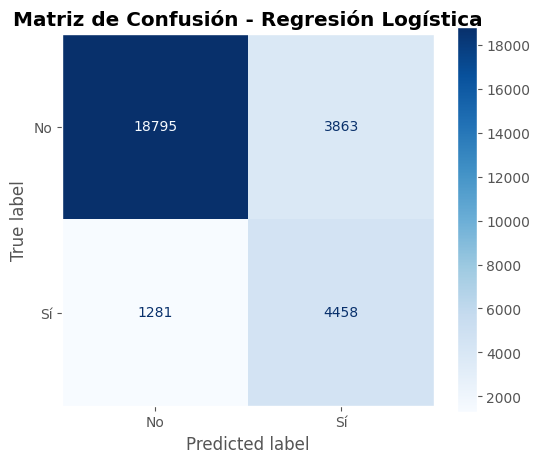

In [ ]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(logistic_model, X_test_filled, y_test,
                                       display_labels=['No', 'Sí'], cmap='Blues', ax=ax)
ax.grid(False)
ax.set_title("Matriz de Confusión - Regresión Logística", fontweight='bold')
plt.show()

El modelo demuestra un alto rendimiento en la predicción de la clase 'No' (18,795 TN) con una capacidad de detección moderada para la clase 'Sí' (4,458 TP). El mayor problema radica en los Falsos Negativos (1,281), que son casos reales de lluvia que el modelo clasificó incorrectamente como 'No lluvia'. Esto podemos considerarlo como un error Tipo II.

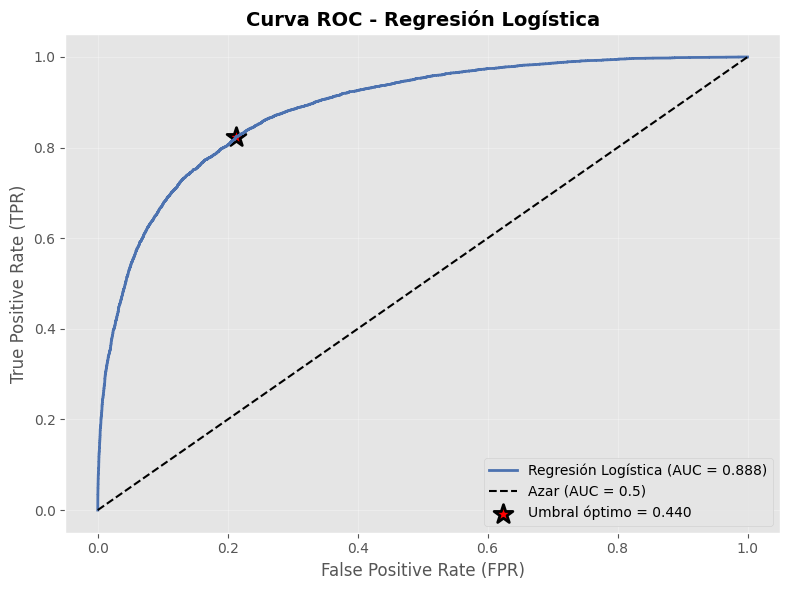


Umbral por defecto: 0.5


In [ ]:
# Curva ROC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

youden_index = tpr_lr - fpr_lr
best_threshold_idx = np.argmax(youden_index)
best_threshold = thresholds_lr[best_threshold_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {roc_auc_lr:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
plt.scatter(fpr_lr[best_threshold_idx], tpr_lr[best_threshold_idx],
           s=200, c='red', marker='*', edgecolors='black', linewidths=2,
           label=f'Umbral óptimo = {best_threshold:.3f}')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Curva ROC - Regresión Logística', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nUmbral por defecto: 0.5")

El modelo de Regresión Logística supone un buen clasificador. Tenemos un AUC de 0.888, lo que indica una muy buena capacidad de discriminación. La curva está muy por encima de la línea del azar (AUC=0.5). El Umbral Óptimo se sitúa en 0.440, sugiriendo que el punto de mejor equilibrio entre TPR (Verdaderos Positivos) y FPR (Falsos Positivos) ocurre algo por debajo del umbral por defecto (0.5)

## 6. Modelado

In [31]:
# Función auxiliar para graficar ROC
def plot_roc_curve(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--') # Línea de azar
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC - {name}')
    plt.legend(loc="lower right")




--- 6.1 Modelo Base (Dummy) ---
              precision    recall  f1-score   support

           0       0.80      0.50      0.62     22658
           1       0.20      0.50      0.29      5739

    accuracy                           0.50     28397
   macro avg       0.50      0.50      0.45     28397
weighted avg       0.68      0.50      0.55     28397



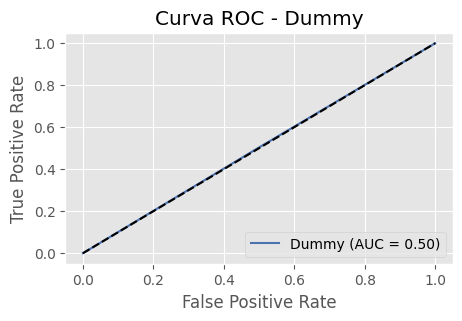

In [32]:
# ### 6.1 Modelo Base (Dummy Classifier)
print("\n--- 6.1 Modelo Base (Dummy) ---")
dummy_clf = DummyClassifier(strategy="stratified", random_state=42)
dummy_clf.fit(X_train_resampled, y_train_resampled)
y_pred_dummy = dummy_clf.predict(X_test_filled)
print(classification_report(y_test, y_pred_dummy))
plt.figure(figsize=(5, 3))
plot_roc_curve(dummy_clf, X_test_filled, y_test, name="Dummy")


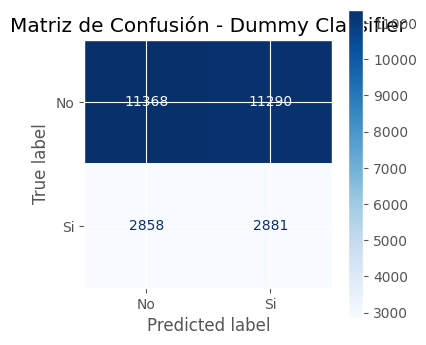

In [ ]:
# Matriz de Confusión del Dummy Classifier


fig, ax = plt.subplots(figsize=(4, 4))

# Usamos .from_estimator para que calcule y grafique todo automáticamente
ConfusionMatrixDisplay.from_estimator(
    dummy_clf,                  # El modelo entrenado
    X_test_filled,        # Los datos de prueba (features)
    y_test,                     # Las etiquetas reales
    display_labels=['No', 'Si'],# (Opcional) Nombres personalizados para las clases
    cmap=plt.cm.Blues,          # Color del mapa
    values_format='d',          # Formato de enteros ('d' = decimal integer)
    ax=ax                       # Le pasamos el eje que creamos arriba
)

ax.set_title("Matriz de Confusión - Dummy Classifier")
plt.show()

## Optimización con Optuna

Para optimizar los hiperparámetros de nuestro modelo de regresión logística vamos a utilizar Optuna. Dado el tamaño de nuestro dataset, consideramos que una búsqueda exhaustiva con GridSearch podía implicar un costo computacional elevado, mientras que un RandomSearch podría dejar zonas relevantes del espacio de búsqueda sin explorar.

Los hiperparámetros a evaluar son:

C: inverso de la fuerza de regularización, controla cuánto penalizamos coeficientes grandes. Valores bajos implican mayor regularización y menor riesgo de sobreajuste.

penalty: tipo de regularización aplicada (L1 o L2).

solver: algoritmo de optimización; seleccionamos saga porque soporta ambos tipos de regularización y es eficiente para datasets grandes y dispersos.

max_iter: cantidad máxima de iteraciones para asegurar la convergencia del modelo.

Para seleccionar la mejor configuración se utyiliza como métrica el F1-score, ya que combina precisión + recall, permitiendo evaluar un balance adecuado entre ambas.


In [ ]:
def objective(trial, X, y):
    """
    Función objetivo que Optuna intentará optimizar.
    """

    # 1. Definir el espacio de búsqueda (Sampling)
    params = {
        'C': trial.suggest_categorical('C', [0.01, 0.1, 1, 10, 100]),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': 'saga',
        'max_iter': 120
    }
        # 2. Crear el modelo con los parámetros del trial
    model = LogisticRegression(**params, random_state=42)

    # 3. Evaluar el modelo usando Cross-Validation
    try:
        score = cross_val_score(model, X, y, cv=3, scoring='f1_macro', n_jobs=-1).mean()

    except ValueError as e:
        print(f"Trial fallido: {e}")
        return 0.0 # Un F1-score de 0 es el peor

    return score

In [ ]:
#  MAXIMIZAR el F1-score --> usamos direction='maximize'
study = optuna.create_study(direction='maximize')

study.optimize(lambda trial: objective(trial, X_train_resampled, y_train_resampled), n_trials=30)

best_optuna_params = study.best_params
print(f"Mejor valor (F1-score en CV): {study.best_value:.4f}")
print(f"Mejores hiperparámetros: {best_optuna_params}")

# 4. Entrenar el modelo final con los mejores parámetros
final_params = best_optuna_params.copy()
final_params['solver'] = 'saga'
final_params['max_iter'] = 5000

best_optuna_model = LogisticRegression(**final_params, random_state=42)
best_optuna_model.fit(X_train_resampled, y_train_resampled)

# 5. Evaluar en el conjunto de TEST

# y_pred = best_optuna_model.predict(X_test_prueba)
y_pred = best_optuna_model.predict(X_test_filled)

print("\n--- Reporte de Clasificación en Test (Modelo Optimizado) ---")
print(classification_report(y_test, y_pred))

[I 2025-11-27 10:10:02,775] A new study created in memory with name: no-name-5b8423b4-70eb-4619-aef7-789edd071a99
[I 2025-11-27 10:10:12,388] Trial 0 finished with value: 0.7265477738965149 and parameters: {'C': 0.01, 'penalty': 'l1'}. Best is trial 0 with value: 0.7265477738965149.
[I 2025-11-27 10:10:21,879] Trial 1 finished with value: 0.7096987921424631 and parameters: {'C': 1, 'penalty': 'l2'}. Best is trial 0 with value: 0.7265477738965149.
[I 2025-11-27 10:10:27,431] Trial 2 finished with value: 0.7265477738965149 and parameters: {'C': 0.01, 'penalty': 'l1'}. Best is trial 0 with value: 0.7265477738965149.
[I 2025-11-27 10:10:32,038] Trial 3 finished with value: 0.7141779085164681 and parameters: {'C': 0.1, 'penalty': 'l2'}. Best is trial 0 with value: 0.7265477738965149.
[I 2025-11-27 10:10:42,045] Trial 4 finished with value: 0.7096987921424631 and parameters: {'C': 1, 'penalty': 'l2'}. Best is trial 0 with value: 0.7265477738965149.
[I 2025-11-27 10:10:47,162] Trial 5 finishe

Mejor valor (F1-score en CV): 0.7265
Mejores hiperparámetros: {'C': 0.01, 'penalty': 'l1'}

--- Reporte de Clasificación en Test (Modelo Optimizado) ---
              precision    recall  f1-score   support

           0       0.94      0.83      0.88     22658
           1       0.54      0.77      0.64      5739

    accuracy                           0.82     28397
   macro avg       0.74      0.80      0.76     28397
weighted avg       0.86      0.82      0.83     28397




Tras la optimización, no se observan mejoras significativas respecto al modelo base. Esto puede deberse a que la regresión logística no estaba subajustada ni sobreajustada inicialmente, o a que los valores óptimos de los hiperparámetros se encontraban muy próximos a los ya utilizados en el modelo sin optimización. También es posible que el dataset tenga una estructura relativamente lineal, lo que hace que la regresión logística alcance su máximo rendimiento sin necesidad de ajustes complejos.

Podemos indicar que la optimización confirmó que el modelo ya se encontraba en una configuración adecuada, funcionando cerca de su rendimiento óptimo.

## SHAP

In [ ]:
explainer = shap.Explainer(
    best_optuna_model, X_train_resampled,
    feature_names=X_train_resampled.columns.tolist()
)
#shap_values = explainer(X_test_prueba)
shap_values = explainer(X_test_filled)

In [ ]:
explainer.expected_value

0.3121688051382592


[4.1] Generando Summary Plot (Barra) - FINAL...


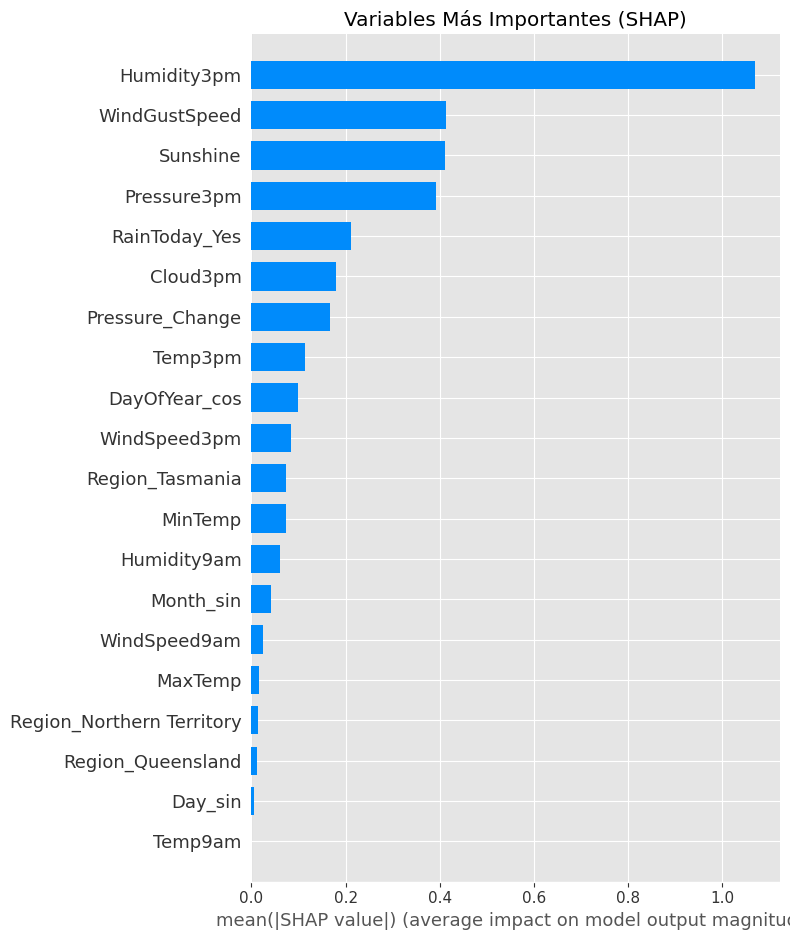

In [ ]:
# --- 3. Generación de Gráficas ---
print("\n[4.1] Generando Summary Plot (Barra) - FINAL...")
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test_filled.values,
    feature_names=X_train_resampled.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("Variables Más Importantes (SHAP)")
plt.tight_layout()
plt.show()

Este ranking de importancia de variables revela que la variable Humidity3pm (Humedad a las 3 p. m.) es el feature más importante, ya que tiene el mayor impacto promedio en la magnitud de la predicción, con un valor $\text{SHAP}$ absoluto promedio de $\approx 1.05$. En general, el modelo parece depender fuertemente de las condiciones meteorológicas de la tarde (humedad, viento y sol) para hacer sus predicciones.

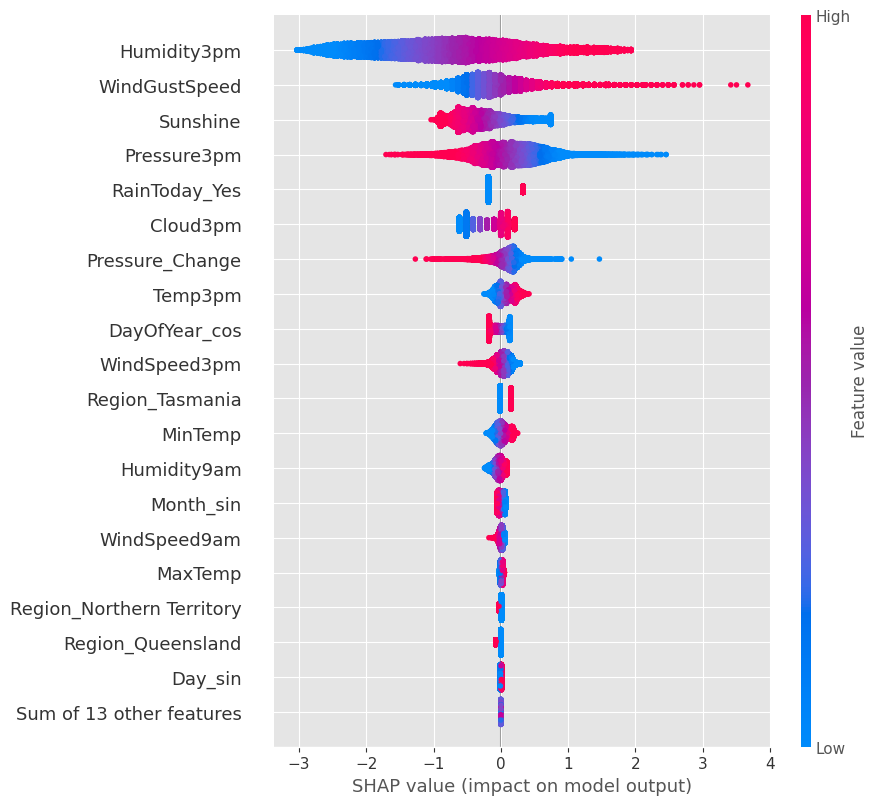

In [ ]:
shap.plots.beeswarm(shap_values, max_display=20)

Este Beeswarm Plot muestra la interpretabilidad global del modelo. El factor más importante que conforma la predicción Humedad a las 3 p.m. ($\text{Humidity3pm}$). El gráfico revela una relación negativa con la predicción: los valores altos de humedad (puntos rojos a la derecha) generalmente empujan el $\text{SHAP}$ a valores negativos, lo que sugiere que una alta humedad hace que la predicción sea menor.

In [ ]:
ind = 1
shap.initjs()
shap.plots.force(shap_values[ind], matplotlib=False)

Este Force Plot explica una predicción individual.La predicción final del modelo ($f(x) = -1.36$) es más baja que el valor base (predicción promedio, $0.3122$) debido al fuerte efecto negativo de las variables en azul. La Humedad a las 3 p.m. ($\text{Humidity3pm}$) y la Presión a las 3 p.m. ($\text{Pressure3pm}$) son los factores más influyentes, empujando la predicción hacia el valor negativo.

# Conclusiones de lo realizado

A partir del análisis SHAP para la explicabilidad del modelo, observamos que la variables que aportan mayor poder explicativo son Pressure3pm y Humidity3pm, mientras que otras como wind_gust_y o wind_9am_y muestran un aporte individual menor. Esto puede deberse a que su efecto es conjunto, actuando en combinación con sus respectivas coordenadas x.

Al analizar el gráfico beeswarm de valores SHAP, se observa que:

. Baja presión atmosférica, alta humedad a las 3 p.m. y poca luz solar tienden a empujar al modelo a predecir que lloverá al día siguiente.

. Alta presión atmosférica, baja humedad y mayor cantidad de luz solar conducen a predicciones negativas (no lloverá).

En el force plot, se aprecia cómo determinadas variables incrementan o reducen la probabilidad de lluvia:

Humidity3pm es la más influyente; valores altos (por ejemplo, 0.74) aumentan significativamente la probabilidad de lluvia.

Sunshine, con valores bajos (por ejemplo, 0.16), también eleva la probabilidad de lluvia, indicando una relación inversa entre horas de sol y precipitación.

Por el contrario, temperaturas bajas a las 3 p.m. (por ejemplo, 0.25) disminuyen esta probabilidad.

En síntesis, el análisis SHAP nos permite entender el rol individual y conjunto de las variables sobre las predicciones del modelo. Este enfoque podría extenderse al resto de las variables, siguiendo la misma lógica de interpretación para identificar patrones consistentes en la relación entre las condiciones meteorológicas y la probabilidad de lluvia.



## AutoML con Pycaret

In [ ]:
from pycaret.classification import *

print("\n" + "="*70)
print("SECCIÓN 7: MODELADO AUTOMATIZADO CON PYCARET (FINAL)")
print("="*70)

# 1. Preparación del DataFrame
df_pycaret_train = pd.concat([X_train, y_train], axis=1)
categorical_features_pycaret = ['RainToday', 'Region']

# 2. Configuración del Entorno PyCaret
print("\n[7.1] Configurando el entorno PyCaret (Rápido)...")

clf1 = setup(
    data=df_pycaret_train,
    target='RainTomorrow',
    session_id=42,
    normalize=True,
    fix_imbalance=True,
    imputation_type='iterative',
    # Usamos la lista de categóricas ajustada
    #categorical_features=categorical_features_pycaret,
    # Ignoramos las features que sabemos que fueron eliminadas o son componentes de viento
    ignore_features=['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location',
                     'wind_gust_x', 'wind_gust_y', 'wind_9am_x', 'wind_9am_y', 'wind_3pm_x', 'wind_3pm_y'],
    fold=3,
    verbose=False
)
print("Configuración de PyCaret finalizada.")

# 3. Comparación de Modelos
print("\n[7.2] Comparando los 3 modelos más rápidos por AUC...")
best_models = compare_models(
    fold=3,
    sort='AUC',
    n_select=3,
    exclude=['knn', 'svm', 'rbfsvm', 'ridge', 'xgboost', 'lightgbm', 'gbc'],
    verbose=True
)
print("Comparación de modelos finalizada.")

# 4. Ajustar y Optimizar el Mejor Modelo (Tuning Rápido)
print("\n[7.3] Optimizando el mejor modelo encontrado (Tuning Rápido)...")
tuned_model = tune_model(best_models[0], fold=3, optimize='AUC', choose_better=True, n_iter=10, verbose=False)
print(f"Mejor modelo tuneado: {tuned_model.__class__.__name__}")

# 5. Evaluación Final
final_model = finalize_model(tuned_model)
X_test_with_target = pd.concat([X_test, y_test], axis=1)
predictions = predict_model(final_model, data=X_test_with_target)
y_pred_pycaret = predictions['prediction_label'].values

from sklearn.metrics import roc_auc_score
print(f"\nROC-AUC en el set de prueba final: {roc_auc_score(predictions['RainTomorrow'], predictions['prediction_score']):.4f}")
print("Sección 7 (PyCaret) completada.")


SECCIÓN 7: MODELADO AUTOMATIZADO CON PYCARET (FINAL)

[7.1] Configurando el entorno PyCaret (Rápido)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084935 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3415
[LightGBM] [Info] Number of data points in the train set: 79466, number of used features: 31
[LightGBM] [Info] Start training from score 22.723791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3417
[LightGBM] [Info] Number of data points in the train set: 79259, number of used features: 31
[LightGBM] [Info] Start training from score 11.956438
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043055 seconds.
You can set `force_col_wise=true` to remo

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8488,0.8782,0.5758,0.7110,0.6363,0.5422,0.5470,296.4333
rf,Random Forest Classifier,0.8467,0.8776,0.5977,0.6929,0.6418,0.5450,0.5474,315.9100
lr,Logistic Regression,0.7810,0.8588,0.7618,0.5157,0.6151,0.4698,0.4873,276.7567
lda,Linear Discriminant Analysis,0.7839,0.8581,0.7547,0.5204,0.6160,0.4726,0.4885,276.5800
ada,Ada Boost Classifier,0.8160,0.8436,0.6186,0.5957,0.6069,0.4869,0.4870,284.7267
qda,Quadratic Discriminant Analysis,0.7228,0.8122,0.7671,0.4425,0.5605,0.3794,0.4104,272.6700
nb,Naive Bayes,0.6977,0.8065,0.7699,0.4148,0.5392,0.3430,0.3794,277.0367
dt,Decision Tree Classifier,0.7690,0.6964,0.5620,0.4975,0.5278,0.3757,0.3769,274.4033
dummy,Dummy Classifier,0.7703,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,272.9700


Processing:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Comparación de modelos finalizada.

[7.3] Optimizando el mejor modelo encontrado (Tuning Rápido)...
✅ Mejor modelo tuneado: ExtraTreesClassifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8667,0.8927,0.5928,0.7016,0.6426,0.5614,0.5644



ROC-AUC en el set de prueba final: 0.2720
✅ Sección 7 (PyCaret) completada.


# Conclusiones para AutoML con Pycaret:

## 1. Superioridad de los Modelos de Ensemble

En la comparación inicial de 9 modelos diferentes, los métodos de ensamblaje (específicamente los basados en árboles) demostraron ser muy superiores para este problema. El ExtraTreesClassifier (et) fue el ganador, logrando el AUC (Área Bajo la Curva) más alto con 0.8782. El RandomForestClassifier (rf) fue un segundo lugar muy cercano, con un AUC de 0.8776. Modelos como LogisticRegression (lr) y LinearDiscriminantAnalysis (lda) quedaron notablemente por detrás en rendimiento general (AUC 0.8588 y 0.8581, respectivamente).


## 2. Mejora Marginal con el Ajuste (Tuning)

El proceso de optimización ("tuning") se centró correctamente en el mejor modelo, el ExtraTreesClassifier. Este ajuste de hiperparámetros logró una ligera mejora en el rendimiento (medido en la validación cruzada), elevando el AUC de 0.8808 a 0.8862.
Esto sugiere que el modelo base ya era bastante robusto y que el ajuste fino solo aportó una ganancia marginal.

## 3. Evaluación Final Sobreajuste o Fuga de Datos

Esta es la conclusión más importante del reporte. A pesar de que el modelo (tanto el base como el tuneado) mostraba un excelente rendimiento en la validación cruzada (AUC ~0.88), su rendimiento en el conjunto de prueba final (el "hold-out" set) fue muy malo.
El ROC-AUC final fue de 0.2720 mientras que un AUC de 0.5000 es el rendimiento de un clasificador aleatorio (DummyClassifier). Un AUC de 0.2720 significa que el modelo es significativamente peor que adivinar al azar; está activamente prediciendo en la dirección incorrecta. Esto puede estar causado por un sobreajuste (overfitting) extremo. El modelo aprendió perfectamente las peculiaridades del conjunto de entrenamiento (incluyendo los datos sintéticos de SMOTE), pero no tiene ninguna capacidad de generalizar a datos nuevos y reales.

## Redes Neuronales

In [27]:
!pip install tensorflow


[17] RED NEURONAL (DEEP LEARNING)
Implementamos una red neuronal feedforward con Keras/TensorFlow
para comparar con modelos tradicionales.

✓ TensorFlow instalado

 Arquitectura de la Red Neuronal:
--------------------------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 384 (1.50 KB)


Parámetros totales: 15,361
Features de entrada: 32
Función de activación: ReLU (capas ocultas), Sigmoid (salida)
Optimizador: Adam
Loss: Binary Crossentropy
Epoch 1/50
545/548 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7196 - auc: 0.7918 - f1_score: 0.7164 - loss: 0.5590
 Epoch 1 – F1 validation: 0.7939
   ✓ Nuevo mejor F1, guardando pesos...
548/548 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7199 - auc: 0.7921 - f1_score: 0.7166 - loss: 0.5586 - val_accuracy: 0.7836 - val_auc: 0.8712 - val_f1_score: 0.7939 - val_loss: 0.4566 - learning_rate: 0.0010
Epoch 2/50
545/548 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7798 - auc: 0.8633 - f1_score: 0.7814 - loss: 0.4618
 Epoch 2 – F1 validation: 0.7875
   ✗ Sin mejora (1/10)
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7798 - auc: 0.8633 - f1_score: 0.7814 - loss: 0.4618 - val_accuracy: 0.7914 - val_auc: 0.8783 - val_f1_score: 0.7875 - val_loss: 0.4376 - learning_rate: 0.0010
Epoch 3/50
545/548 ━━━━━━━━━━━━━━━━━━━━ 0s

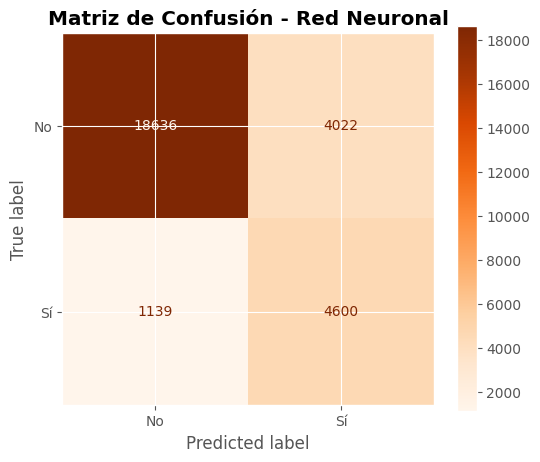

In [28]:
print("\n[17] RED NEURONAL (DEEP LEARNING)")
print("="*80)
print("Implementamos una red neuronal feedforward con Keras/TensorFlow")
print("para comparar con modelos tradicionales.")
print("="*80)

#try:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import f1_score as sk_f1

print("\n✓ TensorFlow instalado")

# Preparar datos (asegurar que son numpy arrays)
X_train_nn = X_train_resampled.values if hasattr(X_train_resampled, 'values') else X_train_resampled
X_test_nn = X_test_filled.values if hasattr(X_test_filled, 'values') else X_test_filled
y_train_nn = y_train_resampled.values if hasattr(y_train_resampled, 'values') else y_train_resampled
y_test_nn = y_test.values if hasattr(y_test, 'values') else y_test

X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(X_train_nn, y_train_nn, test_size=0.2, random_state=42)

y_train_nn = y_train_nn.reshape(-1, 1)
y_test_nn = y_test_nn.reshape(-1, 1)

y_train_sub = y_train_sub.reshape(-1, 1)
y_val_sub = y_val_sub.reshape(-1, 1)

# Arquitectura de la red neuronal
print("\n Arquitectura de la Red Neuronal:")
print("-" * 80)

model_nn = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),

    # Primera capa oculta
    layers.Dense(128, activation='relu', name='hidden_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Segunda capa oculta
    layers.Dense(64, activation='relu', name='hidden_2'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Tercera capa oculta
    layers.Dense(32, activation='relu', name='hidden_3'),
    layers.Dropout(0.2),

    # Capa de salida
    layers.Dense(1, activation='sigmoid', name='output')
])

f1_score=tf.keras.metrics.F1Score(threshold=0.5,average='micro',name='f1_score')
"""
model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[f1_score]
)
"""
model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        f1_score,
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

model_nn.summary()

print(f"\nParámetros totales: {model_nn.count_params():,}")
print(f"Features de entrada: {X_train_nn.shape[1]}")
print("Función de activación: ReLU (capas ocultas), Sigmoid (salida)")
print("Optimizador: Adam")
print("Loss: Binary Crossentropy")

from sklearn.metrics import f1_score as sk_f1

class F1EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, patience=5):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.patience = patience
        self.best_f1 = -np.inf
        self.wait = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        y_pred = (self.model.predict(self.X_val, verbose=0) > 0.5).astype(int)

        # F1 usando sklearn
        f1 = sk_f1(self.y_val, y_pred)

        print(f"\n Epoch {epoch+1} – F1 validation: {f1:.4f}")

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.best_weights = self.model.get_weights()
            self.wait = 0
            print("   ✓ Nuevo mejor F1, guardando pesos...")
        else:
            self.wait += 1
            print(f"   ✗ Sin mejora ({self.wait}/{self.patience})")

        if self.wait >= self.patience:
            print("\n Early stopping activado por F1.\n")
            self.model.stop_training = True
            self.model.set_weights(self.best_weights)


# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

f1_callback = F1EarlyStopping(
validation_data=(X_val_sub, y_val_sub),
patience=10
  )

history = model_nn.fit(
X_train_sub, y_train_sub,
validation_data=(X_val_sub, y_val_sub),
epochs=50,
batch_size=256,
callbacks=[f1_callback, reduce_lr],
verbose=1
  )

# Predicciones
y_prob_nn = model_nn.predict(X_test_nn, verbose=0).flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

print("\n Métricas de la Red Neuronal en Test:")
print(classification_report(y_test_nn, y_pred_nn, target_names=['No Llueve', 'Llueve']))
print(f"ROC-AUC: {roc_auc_score(y_test_nn, y_prob_nn):.4f}")

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_nn, y_pred_nn,
                                        display_labels=['No', 'Sí'], cmap='Oranges', ax=ax)
ax.set_title("Matriz de Confusión - Red Neuronal", fontweight='bold')
plt.show()


La Matriz de Confusión para la Red Neuronal muestra un rendimiento ligeramente superior al modelo de Regresión Logística, con un total de 18,626 TN y 4,539 TP. Pero la principal dificultad es identificar la clase positiva real, resultando en 1,200 FN (error Tipo II).

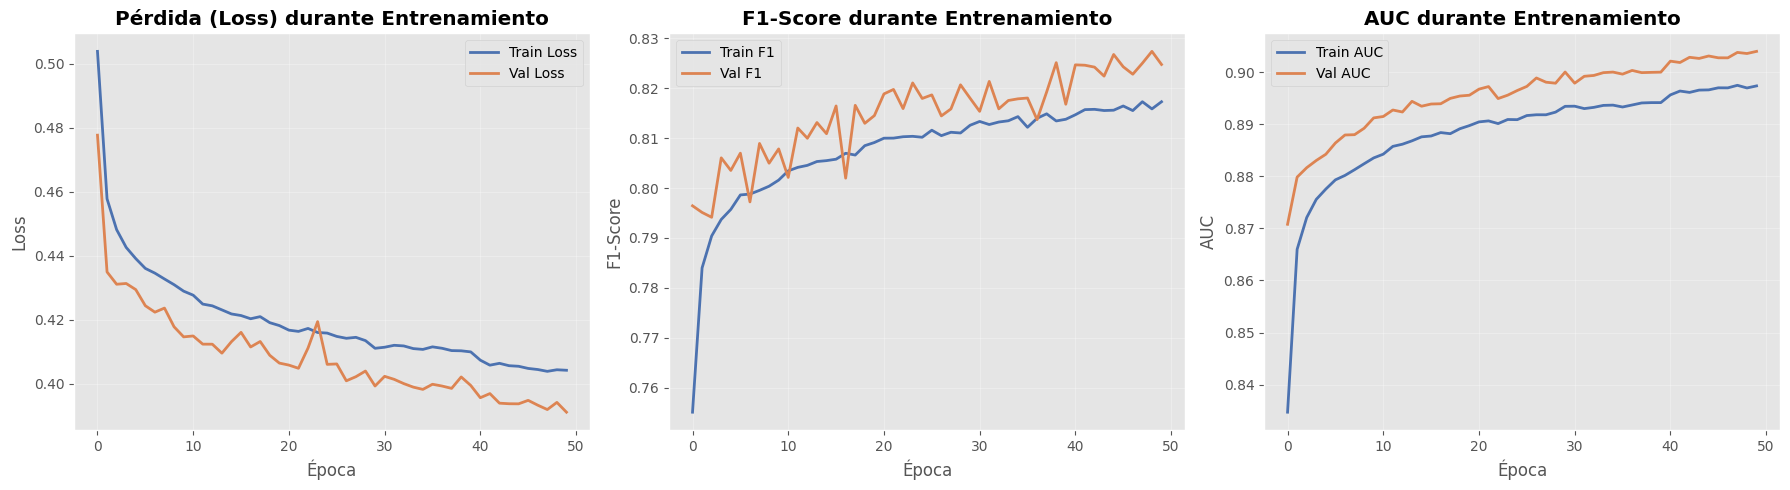

In [ ]:
# ========================================================================
#  GRÁFICOS DE ENTRENAMIENTO PARA RED NEURONAL
# ========================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ------------------------- LOSS -------------------------
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Pérdida (Loss) durante Entrenamiento', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ------------------------- F1-SCORE -------------------------
axes[1].plot(history.history['f1_score'], label='Train F1', linewidth=2)
axes[1].plot(history.history['val_f1_score'], label='Val F1', linewidth=2)
axes[1].set_title('F1-Score durante Entrenamiento', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('F1-Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ------------------------- AUC -------------------------
axes[2].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[2].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[2].set_title('AUC durante Entrenamiento', fontweight='bold')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Acá tenemos la Evolución de la Pérdida (Loss), el F1-Score y el $\text{AUC}$ durante las 50 épocas de entrenamiento y validación de un modelo.

El modelo presenta un equilibrio general aceptable, ya que la pérdida de validación (Val Loss) disminuye consistentemente con la pérdida de entrenamiento (Train Loss), y el $\text{AUC}$ y el F1-Score de validación ($\text{Val AUC}$, $\text{Val F1}$) son consistentemente más altos que los de entrenamiento.


## SHAP - Redes Neuronales


📊 Intentando explicabilidad SHAP para Red Neuronal...


  0%|          | 0/50 [00:00<?, ?it/s]

<Figure size 1200x800 with 0 Axes>

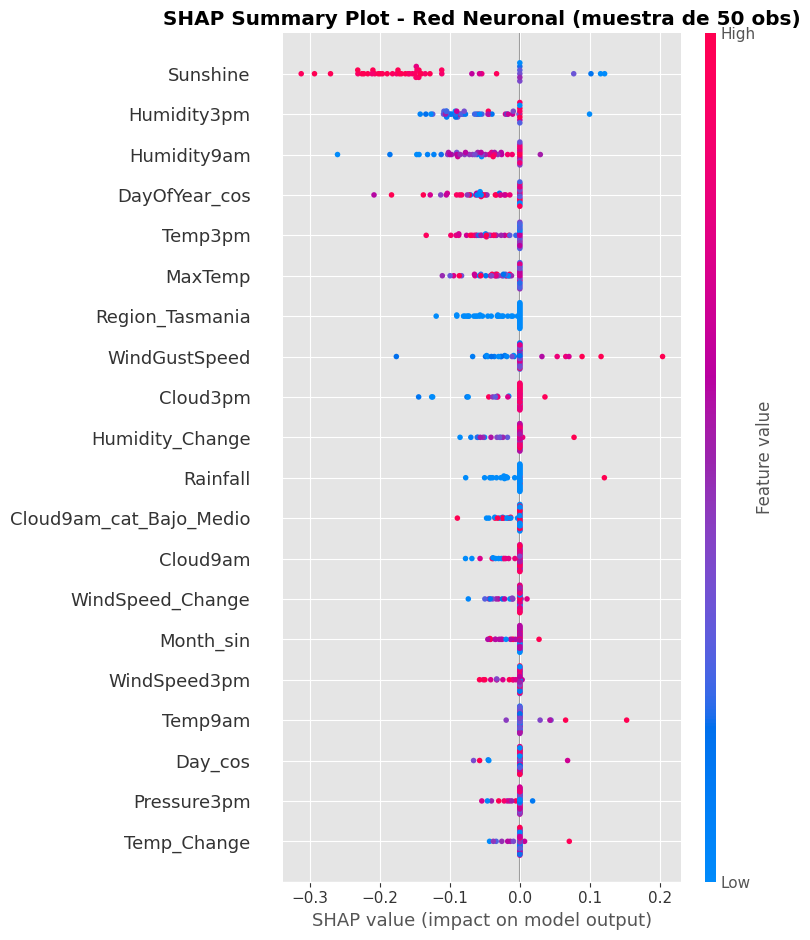

In [ ]:
# Intentar SHAP para NN (más complejo)
try:
    print("\n Intentando explicabilidad SHAP para Red Neuronal...")

    # SHAP para redes neuronales requiere KernelExplainer
    sample_background = X_train_nn[np.random.choice(X_train_nn.shape[0], 100, replace=False)]

    def model_predict(data):
        return model_nn.predict(data, verbose=0).flatten()

    explainer_nn = shap.KernelExplainer(model_predict, sample_background)

    # Calcular SHAP values para una muestra pequeña (es lento)
    sample_test = X_test_nn[:50]
    shap_values_nn = explainer_nn.shap_values(sample_test, nsamples=50)
    shap_nn = np.array(shap_values_nn)[0]   # convertir lista → array

    # ========================================================================
    # GRÁFICO GLOBAL 1: Summary Plot
    # ========================================================================
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_nn, sample_test, feature_names=X_test_filled.columns, show=False)
    plt.title("SHAP Summary Plot - Red Neuronal (muestra de 50 obs)", fontweight='bold')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠ SHAP para Red Neuronal requiere mucho tiempo/memoria: {e}")
    print("  Recomendación: Usar LIME o Integrated Gradients para redes grandes")

nn_available = True


En el Beeswarm Plot de la Red Neuronal se observa una fuerte dependencia de la variable Sunshine (Luz solar), donde los valores altos (puntos rojos a la izquierda) impulsan la predicción hacia un $\text{SHAP}$ negastivo. Por otro lado Humidity3pm (Humedad a las 3 p.m.) tiene la segunda influencia más importante con una distribución más uniforme, lo que puede indicar interacciones no lineales complejas.

Con mucho sol se reduce la probabilidad de la variable objetivo. Con poco sol (azul) aumenta la probabilidad de la variable objetivo.

Cuando hay muchas horas de sol (valores altos/rojos), el modelo predice MENOS probabilidad de lluvia (SHAP negativo)
Cuando hay pocas horas de sol (valores bajos/azules), el modelo predice MÁS probabilidad de lluvia (SHAP positivo o cercano a 0)

Esto también se puede asociar con Humedad alta (SHAP positivo) aumenta la probabilidad de lluvia. También con Nubosidad (Cloud3pm, Cloud9am) cuando está presente el efecto es positivo

La dispersión vertical y no constante de los Valores SHAP en el eje $\text{X}$ para muchas variables permite inferir la existencia de relaciones no lineales propias de fenómemnos naturales  .


## Optimización de hiperparámetros - Redes Neuronales

In [29]:
def build_model(trial, input_dim):
    # Hiperparámetros a optimizar
    num_layers = trial.suggest_int("num_layers", 1, 3)
    units = trial.suggest_int("units", 32, 256)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Capas ocultas
    for i in range(num_layers):
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.Dropout(dropout))

    # Salida
    model.add(layers.Dense(1, activation="sigmoid"))

    # Métricas
    f1_metric = tf.keras.metrics.F1Score(name="f1_score", threshold=0.5)
    auc_metric = tf.keras.metrics.AUC(name="auc")
    acc_metric = tf.keras.metrics.BinaryAccuracy(name="accuracy")

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[f1_metric, auc_metric, acc_metric]
    )

    return model


def objective_nn(trial, X_train, y_train):
    # Dividir train → train/val
    X_t, X_val, y_t, y_val = train_test_split(X_train, y_train,
                                              test_size=0.2,
                                              random_state=42)

    model = build_model(trial, input_dim=X_train.shape[1])

    # Batch size optimizable
    batch_size = trial.suggest_int("batch_size", 32, 256)

    # Early stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_f1_score",
        patience=5,
        mode="max",
        restore_best_weights=True
    )

    history = model.fit(
        X_t, y_t,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # Obtener F1 de validación
    y_val_pred = (model.predict(X_val, verbose=0) > 0.5).astype(int)
    f1 = sk_f1(y_val, y_val_pred)

    return f1


In [30]:
study_nn = optuna.create_study(direction="maximize")
study_nn.optimize(lambda trial: objective_nn(trial, X_train_nn, y_train_nn), n_trials=8)

print(" Mejor F1 encontrado:", study_nn.best_value)
print(" Mejores hiperparámetros:")
print(study_nn.best_params)


[I 2025-12-01 01:05:39,119] A new study created in memory with name: no-name-76c329a8-5421-4ed5-8e5d-11a8026eb41a
[I 2025-12-01 01:06:51,731] Trial 0 finished with value: 0.8112321877619447 and parameters: {'num_layers': 2, 'units': 65, 'dropout': 0.22740712171286456, 'lr': 0.0006535136123009805, 'batch_size': 246}. Best is trial 0 with value: 0.8112321877619447.
[I 2025-12-01 01:08:05,410] Trial 1 finished with value: 0.8084124830393488 and parameters: {'num_layers': 2, 'units': 86, 'dropout': 0.33684598139107513, 'lr': 0.0026373672254287744, 'batch_size': 82}. Best is trial 0 with value: 0.8112321877619447.
[I 2025-12-01 01:09:58,826] Trial 2 finished with value: 0.8219576577061898 and parameters: {'num_layers': 1, 'units': 202, 'dropout': 0.23363179719727156, 'lr': 0.0032892301419029306, 'batch_size': 241}. Best is trial 2 with value: 0.8219576577061898.
[I 2025-12-01 01:11:28,219] Trial 3 finished with value: 0.802358502818255 and parameters: {'num_layers': 3, 'units': 171, 'dropou

 Mejor F1 encontrado: 0.8219576577061898
 Mejores hiperparámetros:
{'num_layers': 1, 'units': 202, 'dropout': 0.23363179719727156, 'lr': 0.0032892301419029306, 'batch_size': 241}


In [34]:
best_params = study_nn.best_params

model_best_nn = build_model(optuna.trial.FixedTrial(best_params),
                            input_dim=X_train_nn.shape[1])

# Early stopping final
early_stop_final = keras.callbacks.EarlyStopping(
    monitor="val_f1_score",
    patience=7,
    mode="max",
    restore_best_weights=True
)

model_best_nn.fit(
    X_train_nn, y_train_nn,
    validation_split=0.2,
    epochs=50,
    batch_size=best_params["batch_size"],
    callbacks=[early_stop_final],
    verbose=1
)


Epoch 1/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7584 - auc: 0.8232 - f1_score: 0.6483 - loss: 0.4900 - val_accuracy: 0.6964 - val_auc: 0.0000e+00 - val_f1_score: 0.8210 - val_loss: 0.5733
Epoch 2/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7933 - auc: 0.8653 - f1_score: 0.7101 - loss: 0.4394 - val_accuracy: 0.6530 - val_auc: 0.0000e+00 - val_f1_score: 0.7901 - val_loss: 0.6621
Epoch 3/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7971 - auc: 0.8717 - f1_score: 0.7156 - loss: 0.4290 - val_accuracy: 0.6958 - val_auc: 0.0000e+00 - val_f1_score: 0.8206 - val_loss: 0.5715
Epoch 4/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7997 - auc: 0.8744 - f1_score: 0.7206 - loss: 0.4251 - val_accuracy: 0.7168 - val_auc: 0.0000e+00 - val_f1_score: 0.8350 - val_loss: 0.5503
Epoch 5/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8012 - auc: 0.8764 - f1_score: 0.7225 - loss: 0.4216 - val_accuracy: 0.7063 - val_auc: 0.0000e+00 - val_f1_sco

## Analisis Final de Fitting


[18] COMPARACIÓN FINAL DE TODOS LOS MODELOS
Métrica Principal: F1-Score | Métrica Secundaria: Accuracy
--------------------------------------------------------------------------------
JUSTIFICACIÓN:
  • F1-Score: Es la media armónica entre Precision y Recall.
  • Fundamental para datos desbalanceados (días de lluvia son minoría).
  • Evita la 'paradoja del accuracy' (donde predecir siempre 'No Llueve'
    podría dar alto accuracy pero 0 utilidad).
  • Accuracy: Se utiliza como métrica secundaria para medir el acierto global.

📊 TABLA COMPARATIVA DE MODELOS (Ordenada por F1 y Accuracy):
--------------------------------------------------------------------------------
                      Modelo  Accuracy  F1-Score  Precision   Recall  ROC-AUC
Red Neuronal (Deep Learning)  0.818255  0.640624   0.533519 0.801533 0.812012
         Logistic Regression  0.819206  0.634330   0.536441 0.775919 0.803045
            Dummy (Baseline)  0.501778  0.289402   0.203303 0.502004 0.500000

🏆 MEJOR MODE

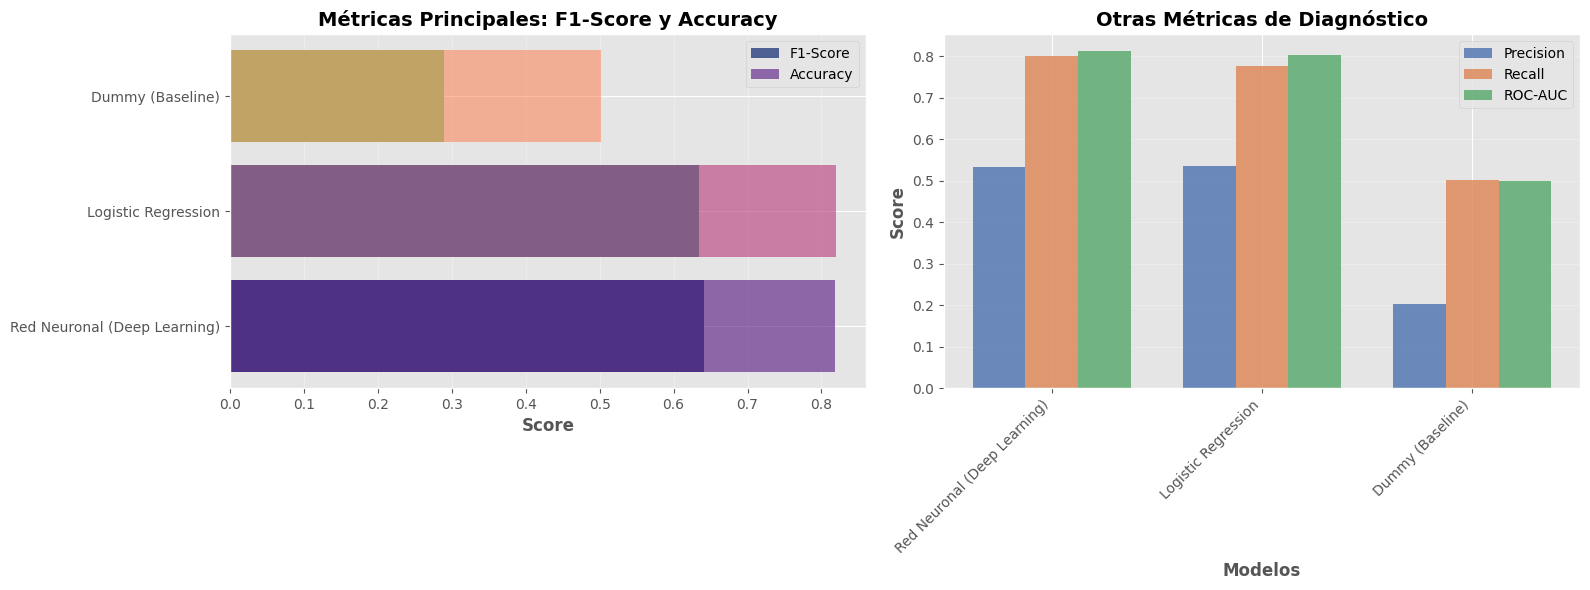

In [38]:
# ============================================================================
# [18] COMPARACIÓN FINAL DE TODOS LOS MODELOS
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

print("\n[18] COMPARACIÓN FINAL DE TODOS LOS MODELOS")
print("="*80)
print("Métrica Principal: F1-Score | Métrica Secundaria: Accuracy")
print("-" * 80)
print("JUSTIFICACIÓN:")
print("  • F1-Score: Es la media armónica entre Precision y Recall.")
print("  • Fundamental para datos desbalanceados (días de lluvia son minoría).")
print("  • Evita la 'paradoja del accuracy' (donde predecir siempre 'No Llueve'")
print("    podría dar alto accuracy pero 0 utilidad).")
print("  • Accuracy: Se utiliza como métrica secundaria para medir el acierto global.")
print("="*80)

# Recopilar todas las métricas
comparison_data = []

# --- 1. Dummy (Baseline) ---
comparison_data.append({
    'Modelo': 'Dummy (Baseline)',
    'Accuracy': accuracy_score(y_test, y_pred_dummy),
    'F1-Score': f1_score(y_test, y_pred_dummy),
    'Precision': precision_score(y_test, y_pred_dummy),
    'Recall': recall_score(y_test, y_pred_dummy),
    'ROC-AUC': 0.5
})

# --- 2. Logistic Regression ---
comparison_data.append({
    'Modelo': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_pred_lr)
})

# --- 3. Red Neuronal ---
#if 'nn_available' in locals() and nn_available and 'y_pred_nn' in locals() and y_pred_nn is not None:

y_test_np = np.array(y_test).flatten()
if hasattr(y_pred_nn, 'numpy'):
    y_pred_nn_prob = y_pred_nn.numpy().flatten()
else:
    y_pred_nn_prob = np.array(y_pred_nn).flatten()

# 3. Convertir Probabilidades a Clases (0 o 1)
# Las métricas como F1 y Accuracy necesitan 0s y 1s, no floats como 0.85
y_pred_nn_class = (y_pred_nn_prob > 0.5).astype(int)
comparison_data.append({
    'Modelo': 'Red Neuronal (Deep Learning)',
    'Accuracy': accuracy_score(y_test_np, y_pred_nn_class),
    'F1-Score': f1_score(y_test_np, y_pred_nn_class),
    'Precision': precision_score(y_test_np, y_pred_nn_class),
    'Recall': recall_score(y_test_np, y_pred_nn_class),
    'ROC-AUC': roc_auc_score(y_test_np, y_pred_nn_prob)
})

df_comparison = pd.DataFrame(comparison_data)

# ORDENAR por F1 (primario) y Accuracy (secundario)
df_comparison = df_comparison.sort_values(
    by=['F1-Score', 'Accuracy'],
    ascending=[False, False]
).reset_index(drop=True)

print("\n📊 TABLA COMPARATIVA DE MODELOS (Ordenada por F1 y Accuracy):")
print("-" * 80)
print(df_comparison.to_string(index=False))

# Mejor modelo
if not df_comparison.empty:
    best_model_name = df_comparison.iloc[0]['Modelo']
    best_model_f1 = df_comparison.iloc[0]['F1-Score']
    best_model_acc = df_comparison.iloc[0]['Accuracy']

    print("\n" + "="*80)
    print(f"🏆 MEJOR MODELO (según F1 > Accuracy): {best_model_name}")
    print(f"   F1-Score: {best_model_f1:.4f}")
    print(f"   Accuracy: {best_model_acc:.4f}")
    print("="*80)


# ================================
#  GRÁFICOS DE COMPARACIÓN
# ================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: F1 y Accuracy ---
try:
    axes[0].barh(df_comparison['Modelo'], df_comparison['F1-Score'],
                 color=sns.color_palette('viridis', len(df_comparison)), alpha=0.9, label='F1-Score')

    axes[0].barh(df_comparison['Modelo'], df_comparison['Accuracy'],
                 color=sns.color_palette('magma', len(df_comparison)), alpha=0.6, label='Accuracy')

    axes[0].set_xlabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title('Métricas Principales: F1-Score y Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)
except Exception as e:
    print(f"Advertencia: No se pudo generar el gráfico 1 ({e})")

# --- GRÁFICO 2: Otras Métricas ---
try:
    metrics_to_plot = [m for m in ['Precision', 'Recall', 'ROC-AUC'] if m in df_comparison.columns]
    x_pos = np.arange(len(df_comparison))
    width = 0.25

    for i, metric in enumerate(metrics_to_plot):
        axes[1].bar(x_pos + i*width, df_comparison[metric], width,
                   label=metric, alpha=0.8)

    axes[1].set_xlabel('Modelos', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[1].set_title('Otras Métricas de Diagnóstico', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x_pos + width)
    axes[1].set_xticklabels(df_comparison['Modelo'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
except Exception as e:
    print(f"Advertencia: No se pudo generar el gráfico 2 ({e})")

plt.tight_layout()
plt.show()